# Solar v7 — Unified kt model + Optuna-tuned XGBoost

**Goal:** Replace v6's monsoon/dry split with a single unified `kt_model_v7`, expand feature engineering (lags, dewpoint, anomalies, second-harmonic seasonality), and tune hyperparameters with Optuna. Lift oracle-free daytime R² from 0.515 toward ≥ 0.60.

**Spec:** `docs/superpowers/specs/2026-05-05-solar-v7-design.md`  
**Plan:** `docs/superpowers/plans/2026-05-05-solar-v7-implementation.md`

Sections mirror v6 for direct comparison. v6 is **frozen** — this notebook does not modify any v6 file.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, pickle, os, json
from datetime import datetime
warnings.filterwarnings("ignore")

from scipy.interpolate import PchipInterpolator
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
from xgboost import XGBRegressor

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)


## 1. Config

v7 — single unified kt model (no monsoon/dry split), expanded feature engineering, Optuna-tuned hyperparameters.

| Model | Training features | Use case |
|---|---|---|
| **kt_model_v7** | weather + time + lags + dewpoint + anomalies (~28) | Predicts kt for any hour, any season |
| **power_model_v7** (oracle-free) | weather + kt-estimated irr features | Day-ahead forecast from weather API |
| **sensor_model_v7** | weather + actual irr features | Real-time SEMS dashboard |

In [2]:

# Paths
DATA_PATH = r"C:\Solar_SUDHA_maam\synthetic_5y.csv"
ART_DIR   = r"C:\Solar_SUDHA_maam\models"
os.makedirs(ART_DIR, exist_ok=True)

# Plant constants (identical to v6)
LATITUDE = 13.04
AREA_EFF = 181.591
RATED_KW = 43.625

# Chronological train/validation/test split.
# Train is used for fitting and Optuna CV, validation is used only for final
# early stopping/model selection, and test is untouched until final metrics.
VAL_DATE  = "2024-01-01"
TEST_DATE = "2024-12-28"

# Daytime gate for kt
SOLAR_ELEV_MIN_DEG = 5.0

# Optuna budget
KT_TRIALS     = 100
POWER_TRIALS  = 100
SENSOR_TRIALS = 30
CV_SPLITS     = 5

# Reproducibility
RANDOM_STATE = 42

# GPU acceleration. XGBoost 3.x uses tree_method="hist" + device="cuda".
# If CUDA is unavailable or the installed XGBoost build cannot use it, fall back to CPU.
USE_GPU = True

def detect_xgb_device(use_gpu: bool = True):
    if not use_gpu:
        return "cpu", "GPU disabled by USE_GPU=False"
    try:
        x_probe = np.array([[0.0], [1.0], [2.0], [3.0]], dtype=np.float32)
        y_probe = np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32)
        probe = XGBRegressor(
            n_estimators=1,
            max_depth=1,
            learning_rate=1.0,
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            random_state=RANDOM_STATE,
            verbosity=0,
        )
        probe.fit(x_probe, y_probe, verbose=False)
        _ = probe.predict(x_probe)
        return "cuda", "CUDA probe succeeded"
    except Exception as exc:
        return "cpu", f"CUDA probe failed: {type(exc).__name__}: {exc}"

XGB_DEVICE, GPU_PROBE_STATUS = detect_xgb_device(USE_GPU)
XGB_BASE_PARAMS = {
    "tree_method": "hist",
    "device": XGB_DEVICE,
    "random_state": RANDOM_STATE,
    "early_stopping_rounds": 30,
    "n_jobs": -1,
}

print(f"Artifacts will be saved to: {ART_DIR}")
print(f"Validation starts: {VAL_DATE}")
print(f"Final test starts: {TEST_DATE}")
print(f"XGBoost version: {xgb.__version__}")
print(f"XGBoost device: {XGB_DEVICE} ({GPU_PROBE_STATUS})")
print(f"Optuna trials - kt: {KT_TRIALS}, power: {POWER_TRIALS}, sensor: {SENSOR_TRIALS}")


Artifacts will be saved to: C:\Solar_SUDHA_maam\models
Validation starts: 2024-01-01
Final test starts: 2024-12-28
XGBoost version: 2.0.3
XGBoost device: cuda (CUDA probe succeeded)
Optuna trials - kt: 100, power: 100, sensor: 30


## 2. Load data

In [3]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.lower()
df["time"] = pd.to_datetime(df["time"], dayfirst=True)
df = df.sort_values("time").reset_index(drop=True)
print(f"Rows: {len(df):,}  |  {df['time'].min().date()} → {df['time'].max().date()}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows: 525,888  |  2021-01-01 → 2025-12-31
Columns: ['time', 'irradiance', 'power', 'theoretical_power', 'temp', 'humidity', 'wind_speed', 'precipitation', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high']


,time,irradiance,power,theoretical_power,temp,humidity,wind_speed,precipitation,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high
0,2021-01-01 00:00:00,0,0.0,0.0,24.09,74.08,9.505,0.0,93.00,56.00,0.0,86.0
1,2021-01-01 00:05:00,0,0.0,0.0,24.08,74.15,9.610,0.0,93.17,57.17,0.0,86.0
2,2021-01-01 00:10:00,0,0.0,0.0,24.05,74.30,9.818,0.0,93.33,58.33,0.0,86.0
3,2021-01-01 00:15:00,0,0.0,0.0,24.02,74.44,10.023,0.0,93.50,59.50,0.0,86.0
4,2021-01-01 00:20:00,0,0.0,0.0,24.00,74.57,10.224,0.0,93.67,60.67,0.0,86.0


In [4]:
# Verification — fail fast if dataset shape changed since v6
EXPECTED_COLS = {"time","irradiance","power","theoretical_power",
                 "temp","humidity","wind_speed","precipitation",
                 "cloud_cover","cloud_cover_low","cloud_cover_mid","cloud_cover_high"}
assert EXPECTED_COLS.issubset(set(df.columns)), \
    f"Missing columns. Got {set(df.columns)}, expected superset of {EXPECTED_COLS}"
assert df["time"].is_monotonic_increasing, "Times are not sorted ascending"
assert len(df) > 500_000, f"Row count {len(df)} unexpectedly small — dataset truncated?"
assert df["time"].min().year == 2021, f"Earliest year is {df['time'].min().year}, expected 2021"
print(f"OK: {len(df):,} rows, columns valid, time-sorted.")

OK: 525,888 rows, columns valid, time-sorted.


## 3. Feature engineering

Builds the v7 feature set onto `df` in place. ~28 features are derived from the 5 raw weather inputs plus `time`. The `is_monsoon` hard flag from v6 is **dropped** — continuous seasonality features (cyclical + 2nd harmonic + anomalies) replace it.

In [5]:
# --- Time-derived ---------------------------------------------------------
df["hour"]      = df["time"].dt.hour + df["time"].dt.minute / 60
df["dayofyear"] = df["time"].dt.dayofyear
df["month"]     = df["time"].dt.month

# Cyclical (first harmonic) — same as v6
for col, period in [("hour", 24), ("dayofyear", 365), ("month", 12)]:
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

# Second harmonic on dayofyear — captures bimodal monsoon-climate seasonality (NEW)
df["dayofyear_sin2"] = np.sin(2 * np.pi * df["dayofyear"] / (365/2))
df["dayofyear_cos2"] = np.cos(2 * np.pi * df["dayofyear"] / (365/2))

# --- Solar geometry (carry over from v6) ----------------------------------
lat_r    = np.radians(LATITUDE)
decl     = np.radians(23.45) * np.sin(np.radians((360/365) * (df["dayofyear"] - 81)))
ha       = np.radians(15 * (df["hour"] - 12))
sin_elev = np.sin(lat_r)*np.sin(decl) + np.cos(lat_r)*np.cos(decl)*np.cos(ha)
df["sin_elev_clipped"] = np.clip(sin_elev, 0, 1)
df["solar_elev"]       = np.degrees(np.arcsin(np.clip(sin_elev, -1, 1)))
df["cs_irr"]           = np.clip(1000 * sin_elev, 0, 1100)
df["cs_power"]         = df["cs_irr"] * AREA_EFF / 1000

# --- New physics features (v7) -------------------------------------------
df["air_mass"] = np.where(
    sin_elev > 0.05,
    1.0 / np.clip(sin_elev, 0.05, 1.0),
    20.0,
)
df["cs_irr_smooth_1h"] = df["cs_irr"].rolling(12, min_periods=1).mean()

print("Physics + cyclical features added.")
print(f"  air_mass range: [{df['air_mass'].min():.3f}, {df['air_mass'].max():.3f}]")
print(f"  cs_irr range:   [{df['cs_irr'].min():.1f}, {df['cs_irr'].max():.1f}] W/m²")
print(f"  solar_elev range (daytime): "
      f"[{df.loc[df['solar_elev']>0,'solar_elev'].min():.2f}, "
      f"{df['solar_elev'].max():.2f}] deg")

Physics + cyclical features added.
  air_mass range: [1.000, 20.000]
  cs_irr range:   [0.0, 1000.0] W/m²
  solar_elev range (daytime): [0.00, 89.92] deg


In [6]:
# Sanity: at solar noon (hour~12) on equinox-ish day, cs_irr should be near 1000.
mask = (df["hour"].between(11.5, 12.5)) & (df["dayofyear"].between(80, 100))
median_noon_cs = df.loc[mask, "cs_irr"].median()
assert 800 < median_noon_cs < 1100, \
    f"cs_irr at solar noon near equinox = {median_noon_cs:.1f}; expected 800–1100"
assert df["cs_irr"].between(0, 1100).all(), "cs_irr out of expected [0,1100] range"
assert (df["air_mass"] >= 1.0).all(), "air_mass should always be ≥ 1.0"
print(f"OK: median cs_irr at noon (eq) = {median_noon_cs:.1f} W/m²")

OK: median cs_irr at noon (eq) = 983.2 W/m²


In [7]:
# --- Anomalies vs monthly mean (carry over hum_anomaly, add temp_anomaly) ---
monthly_hum  = df.groupby("month")["humidity"].transform("mean")
monthly_temp = df.groupby("month")["temp"].transform("mean")
df["hum_anomaly"]  = df["humidity"] - monthly_hum
df["temp_anomaly"] = df["temp"]     - monthly_temp

# Save monthly maps for use by compute_features at inference time
MONTHLY_HUM_MAP  = df.groupby("month")["humidity"].mean().to_dict()
MONTHLY_TEMP_MAP = df.groupby("month")["temp"].mean().to_dict()

# --- Dewpoint and spread (NEW) -----------------------------------------------
df["dewpoint"]             = df["temp"] - ((100 - df["humidity"]) / 5)
df["temp_dewpoint_spread"] = df["temp"] - df["dewpoint"]

# --- Interactions (carry over from v6) --------------------------------------
df["temp_x_elev"] = df["temp"]     * df["sin_elev_clipped"]
df["hum_x_elev"]  = df["humidity"] * df["sin_elev_clipped"]

# --- Lag features at 5-min cadence: 1h = 12 steps (NEW) ---------------------
df["temp_lag1h"]     = df["temp"].shift(12)
df["humidity_lag1h"] = df["humidity"].shift(12)

# --- Rolling precip (NEW) ---------------------------------------------------
df["precip_roll_1h"]  = df["precipitation"].rolling(12,  min_periods=1).sum()
df["precip_roll_3h"]  = df["precipitation"].rolling(36,  min_periods=1).sum()
df["precip_roll_24h"] = df["precipitation"].rolling(288, min_periods=1).sum()

# --- Rolling humidity trend/stability (NEW) ---------------------------------
df["humidity_roll_3h_mean"] = df["humidity"].rolling(36, min_periods=1).mean()
df["humidity_roll_3h_std"]  = df["humidity"].rolling(36, min_periods=2).std().fillna(0)

# --- kt target (only valid when sun is up) ----------------------------------
df["kt"]         = np.where(df["cs_irr"] > 10,
                             (df["irradiance"] / df["cs_irr"]).clip(0, 1.2), 0.0)
df["theo_power"] = df["theoretical_power"]

# --- Actual rolling irradiance — sensor model only --------------------------
df["irr_roll5"]  = df["irradiance"].shift(1).rolling(5,  min_periods=1).mean().fillna(0)
df["irr_roll12"] = df["irradiance"].shift(1).rolling(12, min_periods=1).mean().fillna(0)

print("Weather-derived features added.")
print(f"  temp_anomaly:          mean={df['temp_anomaly'].mean():.3f}, std={df['temp_anomaly'].std():.3f}")
print(f"  hum_anomaly:           mean={df['hum_anomaly'].mean():.3f}, std={df['hum_anomaly'].std():.3f}")
print(f"  dewpoint:              range [{df['dewpoint'].min():.1f}, {df['dewpoint'].max():.1f}] °C")
print(f"  temp_dewpoint_spread:  range [{df['temp_dewpoint_spread'].min():.1f}, {df['temp_dewpoint_spread'].max():.1f}] °C")
print(f"  precip_roll_24h:       max={df['precip_roll_24h'].max():.2f} mm")
print(f"  humidity_roll_3h_std:  median={df['humidity_roll_3h_std'].median():.3f}")
print(f"  Lag NaN at start:       {df['temp_lag1h'].isna().sum()}")


# --- Cloud cover derived features (NEW v7.1) -------------------------------
# Cloud cover comes in 4 raw columns; derive lag and short-term roll for trend.
df["cloud_cover_lag1h"]         = df["cloud_cover"].shift(12)
df["cloud_cover_roll_3h_mean"]  = df["cloud_cover"].rolling(36, min_periods=1).mean()
df["cloud_cover_change_1h"]     = df["cloud_cover"] - df["cloud_cover"].shift(12)
df["cloud_cover_change_1h"]     = df["cloud_cover_change_1h"].fillna(0)


Weather-derived features added.
  temp_anomaly:          mean=-0.000, std=3.065
  hum_anomaly:           mean=0.000, std=15.493
  dewpoint:              range [14.6, 29.1] °C
  temp_dewpoint_spread:  range [0.0, 16.6] °C
  precip_roll_24h:       max=207.90 mm
  humidity_roll_3h_std:  median=2.358
  Lag NaN at start:       12


In [8]:
# Sanity checks
assert abs(df["temp_anomaly"].mean()) < 0.01, "temp_anomaly mean should be ~0"
assert abs(df["hum_anomaly"].mean())  < 0.01, "hum_anomaly mean should be ~0"
assert (df["temp_dewpoint_spread"] >= -0.01).all(), "dewpoint should never exceed temperature"
assert df["temp_lag1h"].isna().sum() == 12, \
    f"Expected exactly 12 lag NaNs at start, got {df['temp_lag1h'].isna().sum()}"
for _c in ["cloud_cover","cloud_cover_low","cloud_cover_mid","cloud_cover_high"]:
    assert df[_c].between(0, 100).all(), f"{_c} out of [0,100] range"
print("OK: anomalies sum to ~0, dewpoint ≤ temp, lag NaNs = 12.")

OK: anomalies sum to ~0, dewpoint ≤ temp, lag NaNs = 12.


## 4. Feature lists

`is_monsoon` is intentionally omitted — see spec §4. Continuous seasonality features (cyclical + 2nd harmonic + anomalies) replace it.

In [9]:
# kt model features — predicts kt from weather + time + derived
WEATHER_FEATS = [
    # raw weather
    "temp", "humidity", "wind_speed", "precipitation",
    # anomalies
    "hum_anomaly", "temp_anomaly",
    # dewpoint family
    "dewpoint", "temp_dewpoint_spread",
    # cyclical seasonality (1st harmonic)
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",
    "month_sin", "month_cos",
    # 2nd harmonic dayofyear (NEW v7)
    "dayofyear_sin2", "dayofyear_cos2",
    # physics
    "solar_elev", "cs_irr", "air_mass", "cs_irr_smooth_1h",
    # interactions
    "temp_x_elev", "hum_x_elev",
    # lags / rolling weather
    "temp_lag1h", "humidity_lag1h",
    "precip_roll_1h", "precip_roll_3h", "precip_roll_24h",
    "humidity_roll_3h_mean", "humidity_roll_3h_std",
    # cloud cover (NEW v7.1) — 4 raw + 3 derived
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "cloud_cover_lag1h", "cloud_cover_roll_3h_mean", "cloud_cover_change_1h",
]

# Sensor model — actual irradiance-derived solar features
FEATURES_SENSOR = WEATHER_FEATS + [
    "cs_power",
    "kt",
    "theo_power",
    "irr_roll5",
    "irr_roll12",
]

# Oracle-free model — kt-estimated solar features (added in §8)
FEATURES_ORACLE = WEATHER_FEATS + [
    "cs_power",
    "kt_est",
    "theo_power_est",
    "irr_roll5_est",
    "irr_roll12_est",
]

print(f"WEATHER_FEATS    (kt input):     {len(WEATHER_FEATS)}")
print(f"FEATURES_SENSOR  (sensor input): {len(FEATURES_SENSOR)}")
print(f"FEATURES_ORACLE  (oracle input): {len(FEATURES_ORACLE)}")

WEATHER_FEATS    (kt input):     36
FEATURES_SENSOR  (sensor input): 41
FEATURES_ORACLE  (oracle input): 41



## 5. Clean and split

Replace inf, drop rows missing any feature/target. Use a chronological train/validation/test split:

- `train`: rows before `VAL_DATE`; used for fitting and Optuna TimeSeriesSplit CV.
- `val`: rows from `VAL_DATE` up to `TEST_DATE`; used for early stopping and model selection.
- `test`: rows from `TEST_DATE` onward; untouched until final metrics and plots.


In [10]:

df = df.replace([np.inf, -np.inf], np.nan)
required = ["power"] + FEATURES_SENSOR
df = df.dropna(subset=required).reset_index(drop=True)
print(f"Rows after clean (drop NaN in power + FEATURES_SENSOR): {len(df):,}")

val_start = pd.Timestamp(VAL_DATE)
test_start = pd.Timestamp(TEST_DATE)
assert val_start < test_start, "VAL_DATE must be earlier than TEST_DATE"

train = df[df["time"] < val_start].copy()
val   = df[(df["time"] >= val_start) & (df["time"] < test_start)].copy()
test  = df[df["time"] >= test_start].copy()

print(f"Train: {len(train):,}  {train['time'].min().date()} -> {train['time'].max().date()}")
print(f"Val  : {len(val):,}  {val['time'].min().date()} -> {val['time'].max().date()}")
print(f"Test : {len(test):,}  {test['time'].min().date()} -> {test['time'].max().date()}")


Rows after clean (drop NaN in power + FEATURES_SENSOR): 525,876
Train: 315,348  2021-01-01 -> 2023-12-31
Val  : 104,256  2024-01-01 -> 2024-12-27
Test : 106,272  2024-12-28 -> 2025-12-31


In [11]:

assert len(train) > 100_000, f"Train rows {len(train)} unexpectedly small"
assert len(val)   > 50_000,  f"Validation rows {len(val)} unexpectedly small"
assert len(test)  > 50_000,  f"Test rows {len(test)} unexpectedly small"
assert train["time"].max() < pd.Timestamp(VAL_DATE), "Train leaked into validation period"
assert val["time"].min() >= pd.Timestamp(VAL_DATE), "Validation starts before VAL_DATE"
assert val["time"].max() < pd.Timestamp(TEST_DATE), "Validation leaked into final test period"
assert test["time"].min() >= pd.Timestamp(TEST_DATE), "Test starts before TEST_DATE"
for col in FEATURES_SENSOR:
    assert col in train.columns, f"Missing in train: {col}"
    assert col in val.columns,   f"Missing in val: {col}"
    assert col in test.columns,  f"Missing in test: {col}"
assert len(WEATHER_FEATS) == 36, f"WEATHER_FEATS count {len(WEATHER_FEATS)}, expected 36"
print(f"OK: train={len(train):,}, val={len(val):,}, test={len(test):,}; chronological split is clean.")


OK: train=315,348, val=104,256, test=106,272; chronological split is clean.



## 6. Stage 1 - Optuna search for kt_model_v7

Single unified model trained on daytime training rows only (`solar_elev > 5`). Optuna uses 5-fold `TimeSeriesSplit` inside the training period. Validation and final test rows are not used during Optuna search.

Best params are locked after Optuna. The validation split is used later only for early stopping. The final test split remains untouched until final evaluation.


In [12]:

# Daytime subsets for kt model training, validation, and final testing.
kt_train = train[train["solar_elev"] > SOLAR_ELEV_MIN_DEG].copy()
kt_val   = val[val["solar_elev"] > SOLAR_ELEV_MIN_DEG].copy()
kt_test  = test[test["solar_elev"] > SOLAR_ELEV_MIN_DEG].copy()

print(f"kt train rows (daytime): {len(kt_train):,}")
print(f"kt val rows   (daytime): {len(kt_val):,}")
print(f"kt test rows  (daytime): {len(kt_test):,}")

X_kt_tr = kt_train[WEATHER_FEATS].values
y_kt_tr = kt_train["kt"].values
X_kt_val = kt_val[WEATHER_FEATS].values
y_kt_val = kt_val["kt"].values
X_kt_te = kt_test[WEATHER_FEATS].values
y_kt_te = kt_test["kt"].values


kt train rows (daytime): 148,269
kt val rows   (daytime): 49,048
kt test rows  (daytime): 49,923


In [13]:

def kt_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1500),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.0, 20.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        **XGB_BASE_PARAMS,
    }
    tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
    fold_r2 = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_kt_tr)):
        model = XGBRegressor(**params)
        model.fit(X_kt_tr[tr_idx], y_kt_tr[tr_idx],
                  eval_set=[(X_kt_tr[va_idx], y_kt_tr[va_idx])],
                  verbose=False)
        pred = np.clip(model.predict(X_kt_tr[va_idx]), 0, 1.2)
        fold_r2.append(r2_score(y_kt_tr[va_idx], pred))
        trial.report(np.mean(fold_r2), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_r2))

kt_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=2),
    study_name="kt_v7",
)
print(f"Starting Optuna search - {KT_TRIALS} trials, {CV_SPLITS}-fold CV, device={XGB_DEVICE}")
print("(this will take a while - single unified model on training rows only)")
kt_study.optimize(kt_objective, n_trials=KT_TRIALS, show_progress_bar=True)
print(f"\nBest kt CV R2: {kt_study.best_value:.4f}")
print(f"Best params  : {kt_study.best_params}")


Starting Optuna search - 100 trials, 5-fold CV, device=cuda
(this will take a while - single unified model on training rows only)


  0%|          | 0/100 [00:00<?, ?it/s]


Best kt CV R2: 0.8105
Best params  : {'n_estimators': 581, 'max_depth': 7, 'learning_rate': 0.05837924271520623, 'subsample': 0.6897216369430137, 'colsample_bytree': 0.7700729417474357, 'reg_alpha': 1.2050477679400025, 'reg_lambda': 16.729096752186432, 'min_child_weight': 1, 'gamma': 0.012650266611551627}


In [14]:

assert kt_study.best_value > 0.20, \
    f"Best kt CV R2 = {kt_study.best_value:.4f} - below 0.20 sanity floor."
KT_BEST_PARAMS = dict(kt_study.best_params)
KT_BEST_PARAMS.update(XGB_BASE_PARAMS)
KT_CV_R2 = float(kt_study.best_value)
print(f"OK: kt_study.best_value = {KT_CV_R2:.4f}; device={KT_BEST_PARAMS['device']}")


OK: kt_study.best_value = 0.8105; device=cuda



## 7. Stage 1b - Train final kt_model_v7

Refit XGBoost with the locked Optuna params on the daytime training set. Use the validation set for early stopping. Compute final kt metrics on train, validation, and untouched test after fitting.


In [15]:

kt_model_v7 = XGBRegressor(**KT_BEST_PARAMS)
kt_model_v7.fit(
    kt_train[WEATHER_FEATS], kt_train["kt"],
    eval_set=[(kt_val[WEATHER_FEATS], kt_val["kt"])],
    verbose=100,
)

kt_pred_train = np.clip(kt_model_v7.predict(kt_train[WEATHER_FEATS]), 0, 1.2)
kt_pred_val   = np.clip(kt_model_v7.predict(kt_val[WEATHER_FEATS]),   0, 1.2)
kt_pred_test  = np.clip(kt_model_v7.predict(kt_test[WEATHER_FEATS]),  0, 1.2)
KT_TRAIN_R2 = r2_score(kt_train["kt"], kt_pred_train)
KT_VAL_R2   = r2_score(kt_val["kt"],   kt_pred_val)
KT_TEST_R2  = r2_score(kt_test["kt"],  kt_pred_test)
print(f"\nkt_model_v7 - train R2 = {KT_TRAIN_R2:.4f}   val R2 = {KT_VAL_R2:.4f}   test R2 = {KT_TEST_R2:.4f}")
print(f"Best iteration: {kt_model_v7.best_iteration}")

print("\nv6 reference: monsoon kt R2=0.4252, dry kt R2=0.2305")
print(f"v7 unified kt final-test R2: {KT_TEST_R2:.4f}")


[0]	validation_0-rmse:0.28339
[100]	validation_0-rmse:0.09447
[200]	validation_0-rmse:0.09234
[300]	validation_0-rmse:0.09171
[400]	validation_0-rmse:0.09139
[500]	validation_0-rmse:0.09117
[559]	validation_0-rmse:0.09117

kt_model_v7 - train R2 = 0.9305   val R2 = 0.9062   test R2 = 0.9076
Best iteration: 529

v6 reference: monsoon kt R2=0.4252, dry kt R2=0.2305
v7 unified kt final-test R2: 0.9076


In [16]:

assert KT_VAL_R2 > 0.20, f"kt validation R2 {KT_VAL_R2:.4f} below 0.20 - unified model failed."
assert KT_TEST_R2 > 0.20, f"kt final-test R2 {KT_TEST_R2:.4f} below 0.20 - unified model failed."
v6_avg = (0.4252 + 0.2305) / 2
if KT_TEST_R2 < v6_avg - 0.05:
    print(f"WARNING: v7 unified kt final-test R2 ({KT_TEST_R2:.4f}) is worse than v6 average ({v6_avg:.4f}) by >0.05.")
    print("Per spec 11.3, fallback plan is sample-weighted hybrid. Flag to user before continuing.")
else:
    print(f"OK: v7 unified kt final-test R2 ({KT_TEST_R2:.4f}) is competitive with v6 average ({v6_avg:.4f}).")


OK: v7 unified kt final-test R2 (0.9076) is competitive with v6 average (0.3279).



## 8. Generate kt-estimated features

Apply `kt_model_v7` to train, validation, and final test frames. The power model trains on the same estimated-feature family it will see at inference.


In [17]:

def add_estimated_features(ds: pd.DataFrame) -> pd.DataFrame:
    """Apply unified kt_model_v7 to produce estimated solar features."""
    ds = ds.copy()
    kt_est = np.clip(kt_model_v7.predict(ds[WEATHER_FEATS]), 0, 1.2)
    kt_est[ds["cs_irr"].values <= 0] = 0.0
    ds["kt_est"]         = kt_est
    ds["irr_est"]        = np.round(ds["cs_irr"] * kt_est).clip(0, 1100)
    ds["theo_power_est"] = ds["irr_est"] * AREA_EFF / 1000
    ds["irr_roll5_est"]  = ds["irr_est"].rolling(5,  min_periods=1).mean()
    ds["irr_roll12_est"] = ds["irr_est"].rolling(12, min_periods=1).mean()
    return ds

train_est = add_estimated_features(train)
val_est   = add_estimated_features(val)
test_est  = add_estimated_features(test)

tr_day = train_est[train_est["cs_irr"] > 10]
va_day = val_est[val_est["cs_irr"] > 10]
te_day = test_est[test_est["cs_irr"] > 10]
print(f"Train kt_est R2: {r2_score(tr_day['kt'], tr_day['kt_est']):.4f}")
print(f"Val   kt_est R2: {r2_score(va_day['kt'], va_day['kt_est']):.4f}")
print(f"Test  kt_est R2: {r2_score(te_day['kt'], te_day['kt_est']):.4f}")


Train kt_est R2: 0.9340
Val   kt_est R2: 0.9123
Test  kt_est R2: 0.9133


In [18]:

for frame_name, frame in [("train_est", train_est), ("val_est", val_est), ("test_est", test_est)]:
    for col in ["kt_est", "irr_est", "theo_power_est", "irr_roll5_est", "irr_roll12_est"]:
        assert col in frame.columns, f"Missing in {frame_name}: {col}"
        assert frame[col].notna().all(), f"NaN in {frame_name}[{col}]"
assert train_est["irr_est"].between(0, 1100).all(), "train_est irr_est out of range"
assert val_est["irr_est"].between(0, 1100).all(), "val_est irr_est out of range"
assert test_est["kt_est"].between(0, 1.2).all(), "test_est kt_est out of range"
print("OK: estimated features present, finite, and in range for train/val/test.")


OK: estimated features present, finite, and in range for train/val/test.



## 9. Stage 2 - Optuna search for power_model_v7

Optuna uses only `train_est[FEATURES_ORACLE] -> power` with TimeSeriesSplit CV. Validation and final test rows are not used in this hyperparameter search.


In [19]:

po_train = train_est.dropna(subset=["power"] + FEATURES_ORACLE).copy()
po_val   = val_est.dropna(subset=["power"] + FEATURES_ORACLE).copy()
po_test  = test_est.dropna(subset=["power"]  + FEATURES_ORACLE).copy()

X_po_tr = po_train[FEATURES_ORACLE].values
y_po_tr = po_train["power"].values
X_po_val = po_val[FEATURES_ORACLE].values
y_po_val = po_val["power"].values
X_po_te = po_test[FEATURES_ORACLE].values
y_po_te = po_test["power"].values

def power_objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1500),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.0, 20.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        **XGB_BASE_PARAMS,
    }
    tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
    fold_r2 = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_po_tr)):
        model = XGBRegressor(**params)
        model.fit(X_po_tr[tr_idx], y_po_tr[tr_idx],
                  eval_set=[(X_po_tr[va_idx], y_po_tr[va_idx])],
                  verbose=False)
        pred = np.clip(model.predict(X_po_tr[va_idx]), 0, None)
        fold_r2.append(r2_score(y_po_tr[va_idx], pred))
        trial.report(np.mean(fold_r2), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_r2))

power_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=2),
    study_name="power_v7",
)
print(f"Starting Optuna search for power model - {POWER_TRIALS} trials, device={XGB_DEVICE}")
power_study.optimize(power_objective, n_trials=POWER_TRIALS, show_progress_bar=True)
print(f"\nBest power CV R2: {power_study.best_value:.4f}")
print(f"Best params     : {power_study.best_params}")

POWER_BEST_PARAMS = dict(power_study.best_params)
POWER_BEST_PARAMS.update(XGB_BASE_PARAMS)
POWER_CV_R2 = float(power_study.best_value)
print(f"Locked power params use device={POWER_BEST_PARAMS['device']}")


Starting Optuna search for power model - 100 trials, device=cuda


  0%|          | 0/100 [00:00<?, ?it/s]


Best power CV R2: 0.9945
Best params     : {'n_estimators': 201, 'max_depth': 3, 'learning_rate': 0.08932901021782017, 'subsample': 0.8600400977068691, 'colsample_bytree': 0.9993804808727245, 'reg_alpha': 5.210467393739629, 'reg_lambda': 4.4610479919431985, 'min_child_weight': 2, 'gamma': 4.488917127581355}
Locked power params use device=cuda


## 10. Stage 2b — Train final power_model_v7 and sensor_model_v7

`sensor_model_v7` uses a smaller refinement search seeded from the power best params.

In [20]:

# --- power_model_v7 ---
power_model_v7 = XGBRegressor(**POWER_BEST_PARAMS)
power_model_v7.fit(
    po_train[FEATURES_ORACLE], po_train["power"],
    eval_set=[(po_val[FEATURES_ORACLE], po_val["power"])],
    verbose=100,
)
print(f"\npower_model_v7 trained. Best iter: {power_model_v7.best_iteration}")

# --- sensor_model_v7 refinement search around power best params ---
se_train = train.dropna(subset=["power"] + FEATURES_SENSOR).copy()
se_val   = val.dropna(subset=["power"] + FEATURES_SENSOR).copy()
se_test  = test.dropna(subset=["power"]  + FEATURES_SENSOR).copy()
X_se_tr = se_train[FEATURES_SENSOR].values
y_se_tr = se_train["power"].values

def sensor_objective(trial: optuna.Trial) -> float:
    params = dict(POWER_BEST_PARAMS)
    params["max_depth"] = trial.suggest_int(
        "max_depth",
        max(3, POWER_BEST_PARAMS["max_depth"]-2),
        min(10, POWER_BEST_PARAMS["max_depth"]+2),
    )
    params["learning_rate"] = trial.suggest_float(
        "learning_rate",
        POWER_BEST_PARAMS["learning_rate"]*0.5,
        POWER_BEST_PARAMS["learning_rate"]*1.5,
        log=True,
    )
    params["reg_lambda"]       = trial.suggest_float("reg_lambda", 0.0, 20.0)
    params["min_child_weight"] = trial.suggest_int("min_child_weight", 1, 20)
    tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
    fold_r2 = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_se_tr)):
        m = XGBRegressor(**params)
        m.fit(X_se_tr[tr_idx], y_se_tr[tr_idx],
              eval_set=[(X_se_tr[va_idx], y_se_tr[va_idx])], verbose=False)
        pred = np.clip(m.predict(X_se_tr[va_idx]), 0, None)
        fold_r2.append(r2_score(y_se_tr[va_idx], pred))
        trial.report(np.mean(fold_r2), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_r2))

sensor_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=2),
    study_name="sensor_v7",
)
print(f"\nStarting Optuna search for sensor model - {SENSOR_TRIALS} trials, device={XGB_DEVICE}")
sensor_study.optimize(sensor_objective, n_trials=SENSOR_TRIALS, show_progress_bar=True)
print(f"Best sensor CV R2: {sensor_study.best_value:.4f}")

SENSOR_BEST_PARAMS = dict(POWER_BEST_PARAMS)
SENSOR_BEST_PARAMS.update(sensor_study.best_params)
SENSOR_BEST_PARAMS.update(XGB_BASE_PARAMS)
SENSOR_CV_R2 = float(sensor_study.best_value)
print(f"Locked sensor params use device={SENSOR_BEST_PARAMS['device']}")

sensor_model_v7 = XGBRegressor(**SENSOR_BEST_PARAMS)
sensor_model_v7.fit(
    se_train[FEATURES_SENSOR], se_train["power"],
    eval_set=[(se_val[FEATURES_SENSOR], se_val["power"])],
    verbose=100,
)
print(f"\nsensor_model_v7 trained. Best iter: {sensor_model_v7.best_iteration}")


[0]	validation_0-rmse:16.33400
[81]	validation_0-rmse:1.45307

power_model_v7 trained. Best iter: 52

Starting Optuna search for sensor model - 30 trials, device=cuda


  0%|          | 0/30 [00:00<?, ?it/s]

Best sensor CV R2: 0.9991
Locked sensor params use device=cuda
[0]	validation_0-rmse:16.25562
[100]	validation_0-rmse:0.45661
[200]	validation_0-rmse:0.37379

sensor_model_v7 trained. Best iter: 200


In [21]:

assert POWER_CV_R2 > 0.30, f"power CV R2 {POWER_CV_R2:.4f} below sanity floor 0.30"
assert SENSOR_CV_R2 > 0.70, f"sensor CV R2 {SENSOR_CV_R2:.4f} below sanity floor 0.70"
assert len(po_val) > 50_000 and len(se_val) > 50_000, "Validation model frames unexpectedly small"
assert len(po_test) > 50_000 and len(se_test) > 50_000, "Final test model frames unexpectedly small"
print(f"OK: power CV R2 = {POWER_CV_R2:.4f}, sensor CV R2 = {SENSOR_CV_R2:.4f}")


OK: power CV R2 = 0.9945, sensor CV R2 = 0.9991


## 11. Evaluation — headline + per-month + v6 comparison

Sensor model: prediction capped by `theo_power` (actual). Oracle model: prediction capped by `theo_power_est` (estimated). Both clipped to `[0, RATED_KW]`.

In [22]:

def evaluate(y_true, y_pred, label=""):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1))) * 100
    print(f"{label}")
    print(f"  R2={r2:.4f}  MAE={mae:.4f} kW  RMSE={rmse:.4f} kW "
          f"({rmse/RATED_KW*100:.2f}% rated)  MAPE={mape:.1f}%")
    return r2, mae, rmse, mape

def score_split(po_frame: pd.DataFrame, se_frame: pd.DataFrame, split_label: str):
    """Attach predictions and return headline metrics for one split."""
    scored_se = se_frame.copy()
    pred_sensor = np.clip(sensor_model_v7.predict(scored_se[FEATURES_SENSOR]), 0, None)
    pred_sensor = np.minimum(pred_sensor, scored_se["theo_power"].values).clip(0, RATED_KW)
    scored_se["pred_sensor"] = pred_sensor

    scored_po = po_frame.copy()
    pred_oracle = np.clip(power_model_v7.predict(scored_po[FEATURES_ORACLE]), 0, None)
    pred_oracle = np.minimum(pred_oracle, scored_po["theo_power_est"].values).clip(0, RATED_KW)
    scored_po["pred_oracle"] = pred_oracle

    day_s_local = scored_se["cs_irr"] > 10
    day_o_local = scored_po["cs_irr"] > 10

    print("=" * 70); print(f"SENSOR MODEL v7 - {split_label}"); print("=" * 70)
    all_s = evaluate(scored_se["power"], pred_sensor, "All rows")
    day_s_metrics = evaluate(scored_se["power"][day_s_local], pred_sensor[day_s_local], "Daytime only")
    print(); print("=" * 70); print(f"ORACLE-FREE MODEL v7 - {split_label}"); print("=" * 70)
    all_o = evaluate(scored_po["power"], pred_oracle, "All rows")
    day_o_metrics = evaluate(scored_po["power"][day_o_local], pred_oracle[day_o_local], "Daytime only")

    metrics = {
        "sensor_all_r2":  all_s[0], "sensor_all_mae":  all_s[1],
        "sensor_day_r2":  day_s_metrics[0], "sensor_day_mae":  day_s_metrics[1],
        "oracle_all_r2":  all_o[0], "oracle_all_mae":  all_o[1],
        "oracle_day_r2":  day_o_metrics[0], "oracle_day_mae":  day_o_metrics[1],
    }
    return scored_po, scored_se, metrics

po_val, se_val, VALIDATION_METRICS = score_split(po_val, se_val, "VALIDATION")
print("\n" + "#" * 70 + "\nFINAL UNTOUCHED TEST METRICS\n" + "#" * 70)
po_test, se_test, HEADLINE_METRICS = score_split(po_test, se_test, "UNTOUCHED TEST")

pred_s = se_test["pred_sensor"].values
pred_o = po_test["pred_oracle"].values
day_s = se_test["cs_irr"] > 10
day_o = po_test["cs_irr"] > 10


SENSOR MODEL v7 - VALIDATION
All rows
  R2=0.9996  MAE=0.2013 kW  RMSE=0.3731 kW (0.86% rated)  MAPE=1.1%
Daytime only
  R2=0.9986  MAE=0.4039 kW  RMSE=0.5285 kW (1.21% rated)  MAPE=2.2%

ORACLE-FREE MODEL v7 - VALIDATION
All rows
  R2=0.9935  MAE=0.6820 kW  RMSE=1.4492 kW (3.32% rated)  MAPE=3.7%
Daytime only
  R2=0.9794  MAE=1.3723 kW  RMSE=2.0559 kW (4.71% rated)  MAPE=7.4%

######################################################################
FINAL UNTOUCHED TEST METRICS
######################################################################
SENSOR MODEL v7 - UNTOUCHED TEST
All rows
  R2=0.9995  MAE=0.2299 kW  RMSE=0.4192 kW (0.96% rated)  MAPE=1.2%
Daytime only
  R2=0.9983  MAE=0.4620 kW  RMSE=0.5943 kW (1.36% rated)  MAPE=2.3%

ORACLE-FREE MODEL v7 - UNTOUCHED TEST
All rows
  R2=0.9940  MAE=0.6576 kW  RMSE=1.3835 kW (3.17% rated)  MAPE=3.4%
Daytime only
  R2=0.9811  MAE=1.3249 kW  RMSE=1.9640 kW (4.50% rated)  MAPE=6.8%


In [23]:

# v6 reference values (locked from solar_v6.ipynb output)
V6 = {
    "sensor_all_r2":  0.9531, "sensor_all_mae":  0.8773,
    "sensor_day_r2":  0.9435, "sensor_day_mae":  1.0433,
    "oracle_all_r2":  0.5978, "oracle_all_mae":  2.8150,
    "oracle_day_r2":  0.5154, "oracle_day_mae":  3.3472,
}

print("=" * 70)
print("v6 vs v7 - direct comparison on final untouched test set")
print("=" * 70)
print(f"{'Metric':<22}{'v6':>10}{'v7':>10}{'delta':>10}")
for k in V6:
    delta = HEADLINE_METRICS[k] - V6[k]
    arrow = "better" if (("r2" in k and delta > 0) or ("mae" in k and delta < 0)) else \
            ("worse" if (("r2" in k and delta < 0) or ("mae" in k and delta > 0)) else "same")
    print(f"{k:<22}{V6[k]:>10.4f}{HEADLINE_METRICS[k]:>10.4f}{delta:>+10.4f}  {arrow}")


v6 vs v7 - direct comparison on final untouched test set
Metric                        v6        v7     delta
sensor_all_r2             0.9531    0.9995   +0.0464  better
sensor_all_mae            0.8773    0.2299   -0.6474  better
sensor_day_r2             0.9435    0.9983   +0.0548  better
sensor_day_mae            1.0433    0.4620   -0.5813  better
oracle_all_r2             0.5978    0.9940   +0.3962  better
oracle_all_mae            2.8150    0.6576   -2.1574  better
oracle_day_r2             0.5154    0.9811   +0.4657  better
oracle_day_mae            3.3472    1.3249   -2.0223  better


In [24]:
po_test["month_name"] = po_test["time"].dt.strftime("%Y-%m")
se_test["month_name"] = se_test["time"].dt.strftime("%Y-%m")

monthly = {}
for m, grp in po_test[day_o].groupby("month_name"):
    y = grp["power"]; p = grp["pred_oracle"]
    monthly[m] = {"Oracle R²":  round(r2_score(y, p), 3),
                  "Oracle MAE": round(mean_absolute_error(y, p), 3)}
for m, grp in se_test[day_s].groupby("month_name"):
    y = grp["power"]; p = grp["pred_sensor"]
    if m in monthly:
        monthly[m]["Sensor R²"]  = round(r2_score(y, p), 3)
        monthly[m]["Sensor MAE"] = round(mean_absolute_error(y, p), 3)

monthly_df = pd.DataFrame(monthly).T[["Sensor R²","Sensor MAE","Oracle R²","Oracle MAE"]]
print(monthly_df.to_string())
WORST_MONTH_ORACLE_R2 = float(monthly_df["Oracle R²"].min())
print(f"\nWorst-month Oracle R²: {WORST_MONTH_ORACLE_R2:.3f}")
print("v6 worst-month Oracle R² was -13.703 (Jan 2025).")

         Sensor R²  Sensor MAE  Oracle R²  Oracle MAE
2024-12      0.998       0.410      0.950       2.042
2025-01      0.998       0.444      0.982       1.283
2025-02      0.998       0.457      0.990       0.988
2025-03      0.998       0.478      0.991       0.982
2025-04      0.998       0.430      0.980       1.334
2025-05      0.998       0.405      0.956       2.013
2025-06      0.998       0.445      0.987       1.162
2025-07      0.998       0.475      0.989       1.077
2025-08      0.999       0.456      0.987       1.179
2025-09      0.998       0.503      0.986       1.114
2025-10      0.998       0.505      0.959       1.815
2025-11      0.998       0.506      0.977       1.484
2025-12      0.998       0.453      0.980       1.345

Worst-month Oracle R²: 0.950
v6 worst-month Oracle R² was -13.703 (Jan 2025).


In [25]:

# Targets per spec, checked only on the final untouched test metrics.
print("\nTarget check on final untouched test set:")
checks = [
    ("Oracle daytime R2    >= 0.60",  HEADLINE_METRICS["oracle_day_r2"] >= 0.60,  HEADLINE_METRICS["oracle_day_r2"]),
    ("Oracle daytime MAE   <= 2.80",  HEADLINE_METRICS["oracle_day_mae"] <= 2.80, HEADLINE_METRICS["oracle_day_mae"]),
    ("Worst-month R2       >= 0.20",  WORST_MONTH_ORACLE_R2 >= 0.20,              WORST_MONTH_ORACLE_R2),
    ("Sensor daytime R2    >= 0.94",  HEADLINE_METRICS["sensor_day_r2"] >= 0.94,  HEADLINE_METRICS["sensor_day_r2"]),
]
for desc, ok, metric_value in checks:
    mark = "PASS" if ok else "MISS"
    print(f"  [{mark}] {desc}  (got {metric_value:.4f})")

if not all(ok for _, ok, _ in checks):
    print("\nOne or more spec targets missed. Ship only if improvements are real and document the bounded result. Do not fake numbers.")
else:
    print("\nAll spec targets met on final untouched test set.")



Target check on final untouched test set:
  [PASS] Oracle daytime R2    >= 0.60  (got 0.9811)
  [PASS] Oracle daytime MAE   <= 2.80  (got 1.3249)
  [PASS] Worst-month R2       >= 0.20  (got 0.9500)
  [PASS] Sensor daytime R2    >= 0.94  (got 0.9983)

All spec targets met on final untouched test set.


## 12. v7 day-plot comparison

Same 4 days v6 used: 2025-01-24, 2025-03-15, 2025-06-11, 2025-10-20.
Three lines per plot: actual, v7 oracle prediction, v7 sensor prediction.
(See section 16 for cross-model analytical comparison: scatter, residuals,
correlation, feature importance, per-hour and per-month error.)


In [27]:
# Load v6 oracle stack (kt_dual + power) for plotting overlays
import pickle as _pkl
V6_DIR = r"C:\Solar_SUDHA_maam\old_models"
with open(os.path.join(V6_DIR, "kt_model_monsoon_v6.pkl"), "rb") as f: kt_v6_mon = _pkl.load(f)
with open(os.path.join(V6_DIR, "kt_model_dry_v6.pkl"),     "rb") as f: kt_v6_dry = _pkl.load(f)
with open(os.path.join(V6_DIR, "oracle_model_v6.pkl"),     "rb") as f: oracle_v6 = _pkl.load(f)

# v6 kt model used these weather features (note: includes is_monsoon, no v7-only feats)
V6_WEATHER_FEATS = [
    "temp", "humidity", "hum_anomaly",
    "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",
    "month_sin", "month_cos",
    "solar_elev", "is_monsoon",
]
# v6 power model — feature NAMES as stored in the booster (no _v6 suffix)
V6_FEATURES_ORACLE = [
    "temp", "humidity", "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",
    "month_sin", "month_cos",
    "solar_elev", "cs_irr", "cs_power",
    "kt_est", "theo_power_est",
    "temp_x_elev", "hum_x_elev",
    "irr_roll5_est", "irr_roll12_est",
]

# Build a v6-input frame with v6's expected column names.
# Use a separate frame so v7 column names (kt_est, etc.) are not overwritten on `test`.
v6_input = test.copy()
v6_input["is_monsoon"] = v6_input["month"].isin([6, 7, 8, 9]).astype(int)
is_mon = v6_input["is_monsoon"].values.astype(bool)
kt_v6 = np.zeros(len(v6_input))
if is_mon.any():
    kt_v6[is_mon]  = np.clip(kt_v6_mon.predict(v6_input.loc[is_mon, V6_WEATHER_FEATS]), 0, 1.2)
if (~is_mon).any():
    kt_v6[~is_mon] = np.clip(kt_v6_dry.predict(v6_input.loc[~is_mon, V6_WEATHER_FEATS]), 0, 1.2)
kt_v6[v6_input["cs_irr"].values <= 0] = 0.0

# Overwrite the v7 estimated-feature columns on this v6_input frame with v6 values
# (we kept a copy via .copy() so this does not affect train/val/test estimated frames anywhere else)
v6_input["kt_est"]         = kt_v6
v6_input["irr_est"]        = np.round(v6_input["cs_irr"] * kt_v6).clip(0, 1100)
v6_input["theo_power_est"] = v6_input["irr_est"] * AREA_EFF / 1000
v6_input["irr_roll5_est"]  = v6_input["irr_est"].rolling(5,  min_periods=1).mean()
v6_input["irr_roll12_est"] = v6_input["irr_est"].rolling(12, min_periods=1).mean()

pred_v6 = np.clip(oracle_v6.predict(v6_input[V6_FEATURES_ORACLE]), 0, None)
pred_v6 = np.minimum(pred_v6, v6_input["theo_power_est"].values).clip(0, RATED_KW)
v6_input["pred_oracle_v6"] = pred_v6

v6_recon_r2 = r2_score(v6_input.loc[v6_input['cs_irr']>10, 'power'],
                       pred_v6[(v6_input['cs_irr']>10).values])
print(f"v6 oracle predictions reconstructed. Daytime R² on the new test set = {v6_recon_r2:.4f}")
print("(v6 was trained on a different distribution; it is shown only as a visual reference for the day-plots in section 12.)")


v6 oracle predictions reconstructed. Daytime R² on the new test set = -2.2866
(v6 was trained on a different distribution; it is shown only as a visual reference for the day-plots in section 12.)


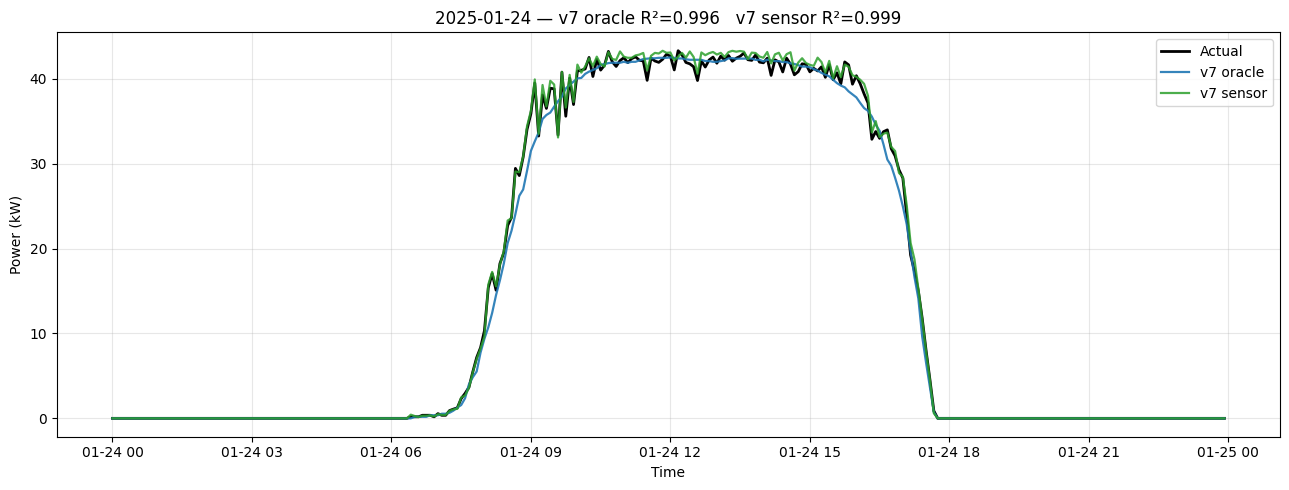

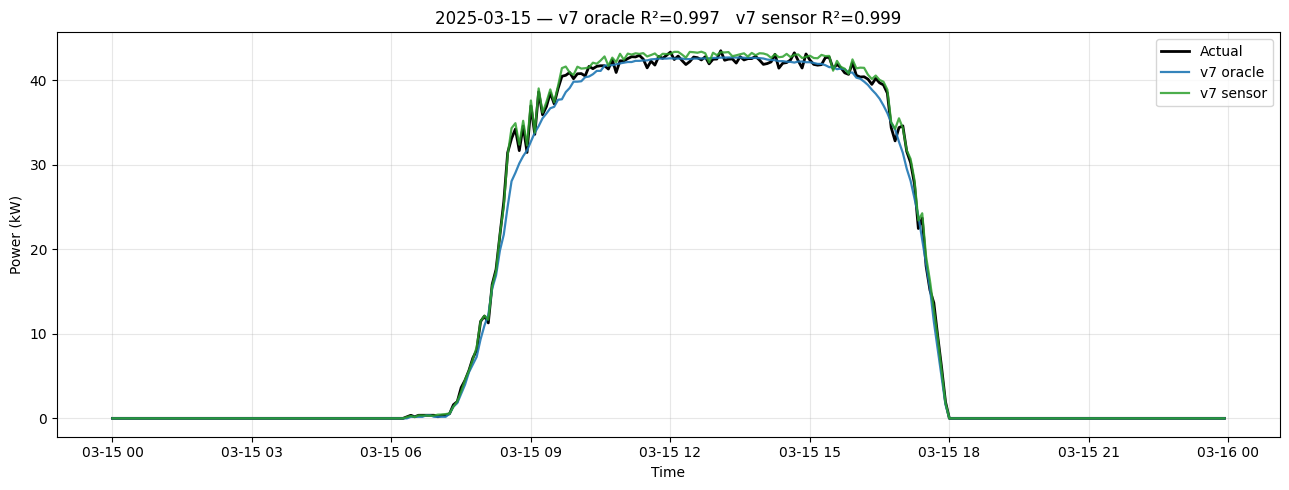

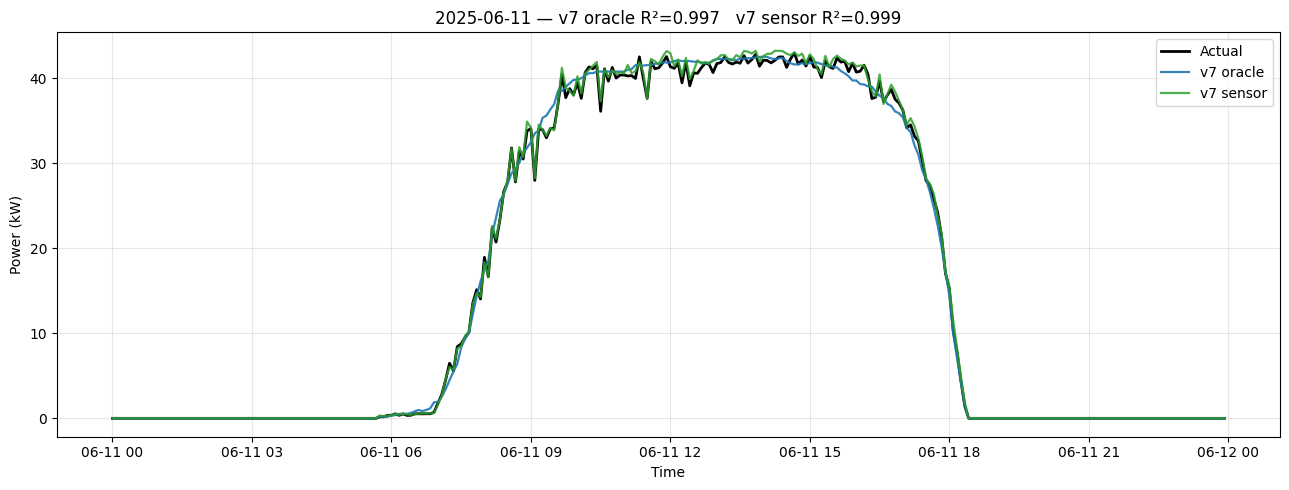

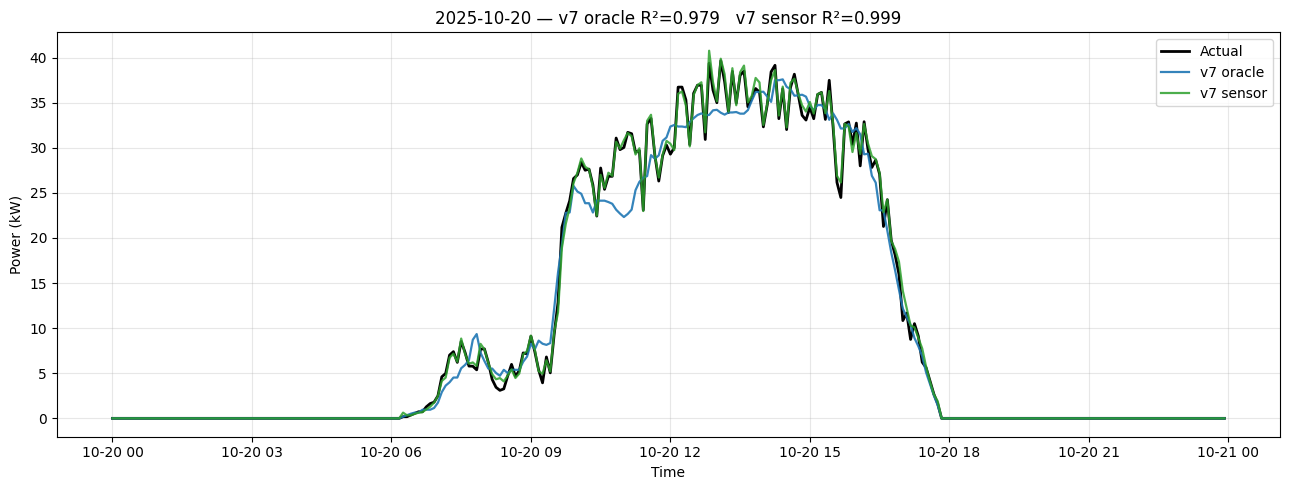

In [28]:
def plot_v7_day(date_string):
    """Plot actual vs v7 oracle vs v7 sensor for a single date."""
    d = pd.to_datetime(date_string).date()
    sel_o  = po_test[po_test["time"].dt.date == d].copy()
    sel_se = se_test[se_test["time"].dt.date == d].copy()
    if sel_o.empty:
        print(f"No test data for {date_string}"); return

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(sel_o["time"], sel_o["power"],       lw=2,   color="black",     label="Actual")
    ax.plot(sel_o["time"], sel_o["pred_oracle"], lw=1.6, color="tab:blue",  alpha=0.9, label="v7 oracle")
    if not sel_se.empty:
        ax.plot(sel_se["time"], sel_se["pred_sensor"], lw=1.6, color="tab:green", alpha=0.85, label="v7 sensor")
    r2_o = r2_score(sel_o["power"], sel_o["pred_oracle"]) if len(sel_o) > 1 else float("nan")
    r2_s = (r2_score(sel_se["power"], sel_se["pred_sensor"])
            if (not sel_se.empty and len(sel_se) > 1) else float("nan"))
    ax.set_title(f"{date_string} — v7 oracle R²={r2_o:.3f}   v7 sensor R²={r2_s:.3f}")
    ax.set_ylabel("Power (kW)"); ax.set_xlabel("Time"); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

for d in ["2025-01-24", "2025-03-15", "2025-06-11", "2025-10-20"]:
    plot_v7_day(d)


## 13. compute_features and forecast_from_hourly (v7)

Same public API as v6:
```python
forecast_from_hourly(date_string, hourly_data, smooth_window=3) -> DataFrame
```
Hourly-data tuples: `(time, temp, humidity, wind_speed, precipitation)`.

Internally: PCHIP-interpolate hourly → 5-min, compute v7 features (lags from the interpolated 5-min series), apply `kt_model_v7`, derive `irr_est`, run `power_model_v7`, smooth, return.

**Cold-start lag handling:** when no preceding-day data is provided, lag values at the start of the day are bfilled from the first valid value (per spec §5.7).

In [29]:
def compute_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Compute all v7 features from weather + timestamp. Caller is responsible for 5-min cadence."""
    out = df_in.copy()

    # Time features
    out["hour"]      = out["time"].dt.hour + out["time"].dt.minute / 60
    out["dayofyear"] = out["time"].dt.dayofyear
    out["month"]     = out["time"].dt.month
    for col, period in [("hour", 24), ("dayofyear", 365), ("month", 12)]:
        out[f"{col}_sin"] = np.sin(2 * np.pi * out[col] / period)
        out[f"{col}_cos"] = np.cos(2 * np.pi * out[col] / period)
    out["dayofyear_sin2"] = np.sin(2 * np.pi * out["dayofyear"] / (365/2))
    out["dayofyear_cos2"] = np.cos(2 * np.pi * out["dayofyear"] / (365/2))

    # Solar geometry
    lat_r  = np.radians(LATITUDE)
    decl   = np.radians(23.45) * np.sin(np.radians((360/365)*(out["dayofyear"]-81)))
    ha     = np.radians(15 * (out["hour"] - 12))
    sin_e  = np.sin(lat_r)*np.sin(decl) + np.cos(lat_r)*np.cos(decl)*np.cos(ha)
    sin_e_clipped = np.clip(sin_e, 0, 1)
    out["sin_elev_clipped"] = sin_e_clipped
    out["solar_elev"] = np.degrees(np.arcsin(np.clip(sin_e, -1, 1)))
    out["cs_irr"]     = np.clip(1000 * sin_e, 0, 1100)
    out["cs_power"]   = out["cs_irr"] * AREA_EFF / 1000
    out["air_mass"]   = np.where(sin_e > 0.05, 1.0 / np.clip(sin_e, 0.05, 1.0), 20.0)
    out["cs_irr_smooth_1h"] = out["cs_irr"].rolling(12, min_periods=1).mean()

    # Anomalies (use TRAINING-SET monthly maps)
    out["hum_monthly_mean"]  = out["month"].map(MONTHLY_HUM_MAP).fillna(out["humidity"].mean())
    out["temp_monthly_mean"] = out["month"].map(MONTHLY_TEMP_MAP).fillna(out["temp"].mean())
    out["hum_anomaly"]  = out["humidity"] - out["hum_monthly_mean"]
    out["temp_anomaly"] = out["temp"]     - out["temp_monthly_mean"]

    # Dewpoint
    out["dewpoint"]             = out["temp"] - ((100 - out["humidity"]) / 5)
    out["temp_dewpoint_spread"] = out["temp"] - out["dewpoint"]

    # Interactions
    out["temp_x_elev"] = out["temp"]     * sin_e_clipped
    out["hum_x_elev"]  = out["humidity"] * sin_e_clipped

    # Lags / rolling weather — bfill on shift NaNs (cold start)
    out["temp_lag1h"]     = out["temp"].shift(12).bfill()
    out["humidity_lag1h"] = out["humidity"].shift(12).bfill()
    out["precip_roll_1h"]  = out["precipitation"].rolling(12,  min_periods=1).sum()
    out["precip_roll_3h"]  = out["precipitation"].rolling(36,  min_periods=1).sum()
    out["precip_roll_24h"] = out["precipitation"].rolling(288, min_periods=1).sum()
    out["humidity_roll_3h_mean"] = out["humidity"].rolling(36, min_periods=1).mean()
    out["humidity_roll_3h_std"]  = out["humidity"].rolling(36, min_periods=2).std().fillna(0)

    # Cloud cover derived (NEW v7.1) — caller must supply 4 raw cloud columns
    for _c in ["cloud_cover","cloud_cover_low","cloud_cover_mid","cloud_cover_high"]:
        if _c not in out.columns:
            raise ValueError(f"compute_features: missing required cloud column {_c}")
    out["cloud_cover_lag1h"]        = out["cloud_cover"].shift(12).bfill()
    out["cloud_cover_roll_3h_mean"] = out["cloud_cover"].rolling(36, min_periods=1).mean()
    out["cloud_cover_change_1h"]    = (out["cloud_cover"] - out["cloud_cover"].shift(12)).fillna(0)

    # kt model + estimated solar features
    kt_e = np.clip(kt_model_v7.predict(out[WEATHER_FEATS]), 0, 1.2)
    kt_e[out["solar_elev"].values <= 0] = 0.0
    out["kt_est"]         = kt_e
    out["irr_est"]        = np.round(out["cs_irr"] * kt_e).astype(int).clip(0, 1100)
    out["theo_power_est"] = out["irr_est"] * AREA_EFF / 1000
    out["irr_roll5_est"]  = out["irr_est"].rolling(5,  min_periods=1).mean()
    out["irr_roll12_est"] = out["irr_est"].rolling(12, min_periods=1).mean()
    return out

In [30]:
def forecast_from_hourly(date_string: str, hourly_data: list,
                          smooth_window: int = 3) -> pd.DataFrame:
    """Day-ahead forecast from hourly weather. Uses oracle-free model throughout.

    Pipeline: weather → PCHIP 5-min interp → v7 features → kt_model_v7
              → irr_est → power_model_v7 → smooth → return.
    """
    hourly = pd.DataFrame(hourly_data,
                          columns=["time","temp","humidity","wind_speed","precipitation",
                                   "cloud_cover","cloud_cover_low","cloud_cover_mid","cloud_cover_high"])
    hourly["time"] = pd.to_datetime(hourly["time"])

    # 5-min target grid (sun hours)
    t5  = pd.date_range(f"{date_string} 05:00", f"{date_string} 19:00", freq="5min")
    t_h = hourly["time"].astype("int64") // 10**9
    t_q = t5.astype("int64") // 10**9
    fm  = pd.DataFrame({"time": t5})

    # PCHIP interpolation
    for col in ["temp", "humidity", "wind_speed",
                "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high"]:
        fn  = PchipInterpolator(t_h, hourly[col].values, extrapolate=False)
        v   = fn(t_q.astype(float))
        v   = np.where(np.isnan(v), np.interp(t_q, t_h, hourly[col].values), v)
        fm[col] = v
    fm["humidity"]   = fm["humidity"].clip(0, 100)
    fm["wind_speed"] = fm["wind_speed"].clip(0)
    for _c in ["cloud_cover","cloud_cover_low","cloud_cover_mid","cloud_cover_high"]:
        fm[_c] = fm[_c].clip(0, 100)

    # Distribute hourly precip uniformly across 12 5-min steps
    prec = np.zeros(len(t5))
    for _, row in hourly.iterrows():
        m = (fm["time"].dt.floor("h") == row["time"].floor("h")).values
        if m.sum() > 0 and row["precipitation"] > 0:
            prec[m] = row["precipitation"] / m.sum()
    fm["precipitation"] = np.round(prec, 4)

    fm = compute_features(fm)

    raw = np.clip(power_model_v7.predict(fm[FEATURES_ORACLE]), 0, RATED_KW)
    raw = np.minimum(raw, fm["theo_power_est"].values)
    raw[fm["solar_elev"].values <= 0] = 0.0
    smooth = pd.Series(raw).rolling(smooth_window, center=True, min_periods=1).median().values
    smooth = np.clip(smooth, 0, RATED_KW)
    fm["predicted_power"] = smooth

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    ax = axes[0]
    ax.fill_between(fm["time"], 0, fm["predicted_power"], alpha=0.2, color="steelblue")
    ax.plot(fm["time"], fm["predicted_power"], lw=2, color="steelblue", label="v7 predicted power")
    ax.plot(fm["time"], fm["cs_power"], lw=1.2, ls=":", color="orange", alpha=0.7, label="Clear-sky ceiling")
    ax.axhline(RATED_KW, lw=0.8, ls="--", color="red", alpha=0.4, label=f"Rated {RATED_KW:.1f} kW")
    ax.set_ylabel("Power (kW)"); ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0)
    ax.set_title(f"v7 day-ahead forecast — {date_string}")

    ax2 = axes[1]
    c1, c2 = "darkorange", "steelblue"
    ln1 = ax2.plot(fm["time"], fm["irr_est"], color=c1, lw=1.5, label="Est. irradiance (W/m²)")
    ax2.set_ylabel("Est. irradiance (W/m²)", color=c1); ax2.tick_params(axis="y", labelcolor=c1)
    ax2r = ax2.twinx()
    ln2 = ax2r.plot(fm["time"], fm["kt_est"], color=c2, lw=1.2, ls="--", label="Estimated kt")
    ax2r.set_ylabel("kt_est", color=c2); ax2r.set_ylim(0, 1.3); ax2r.tick_params(axis="y", labelcolor=c2)
    ax2.legend(ln1+ln2, ["Est. irradiance", "kt_est"], fontsize=9, loc="upper left")
    ax2.grid(alpha=0.3); ax2.set_xlabel("Time (IST)")
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

    peak   = fm["predicted_power"].max()
    energy = fm["predicted_power"].sum() * 5 / 60
    print(f"Peak power  : {peak:.2f} kW")
    print(f"Total energy: {energy:.2f} kWh")
    return fm[["time","predicted_power","irr_est","kt_est","cs_power"]]

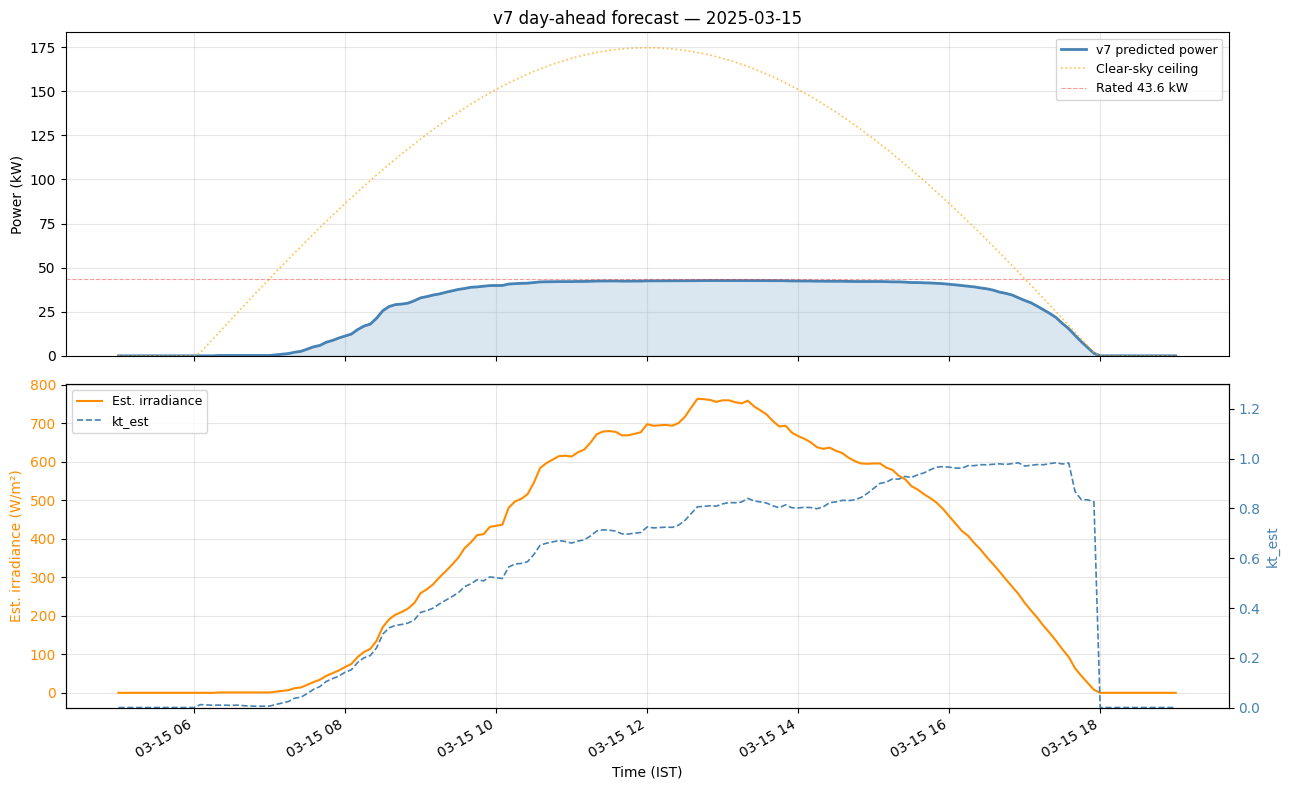

Peak power  : 42.66 kW
Total energy: 372.01 kWh
OK: forecast for 2025-03-15 — peak 42.66 kW, energy 372.01 kWh


In [31]:
# Smoke test: pick 25 hourly tuples from the actual dataset for a known day.
smoke_day = "2025-03-15"
smoke_window = df[(df["time"] >= pd.Timestamp(smoke_day) - pd.Timedelta(hours=1)) &
                  (df["time"] <  pd.Timestamp(smoke_day) + pd.Timedelta(days=1, hours=1))]
smoke_hourly = (
    smoke_window.set_index("time")[["temp","humidity","wind_speed","precipitation",
                                     "cloud_cover","cloud_cover_low","cloud_cover_mid","cloud_cover_high"]]
    .resample("1h").mean()
    .reset_index()
)
smoke_tuples = list(smoke_hourly.itertuples(index=False, name=None))
fm_out = forecast_from_hourly(smoke_day, smoke_tuples)
assert len(fm_out) > 100, f"Forecast row count {len(fm_out)} unexpectedly small"
assert fm_out["predicted_power"].between(0, RATED_KW).all(), "Forecast out of [0, RATED_KW]"
assert fm_out["predicted_power"].max() > 0.5, "Forecast peak too low for a sunny March day"
print(f"OK: forecast for {smoke_day} — peak {fm_out['predicted_power'].max():.2f} kW, "
      f"energy {fm_out['predicted_power'].sum()*5/60:.2f} kWh")

## 14. Day-ahead forecasts — Sep 2026 and Feb 2027

Same hardcoded weather inputs v6 used. Allows visual comparison between v6 §14 and v7 §14 outputs.

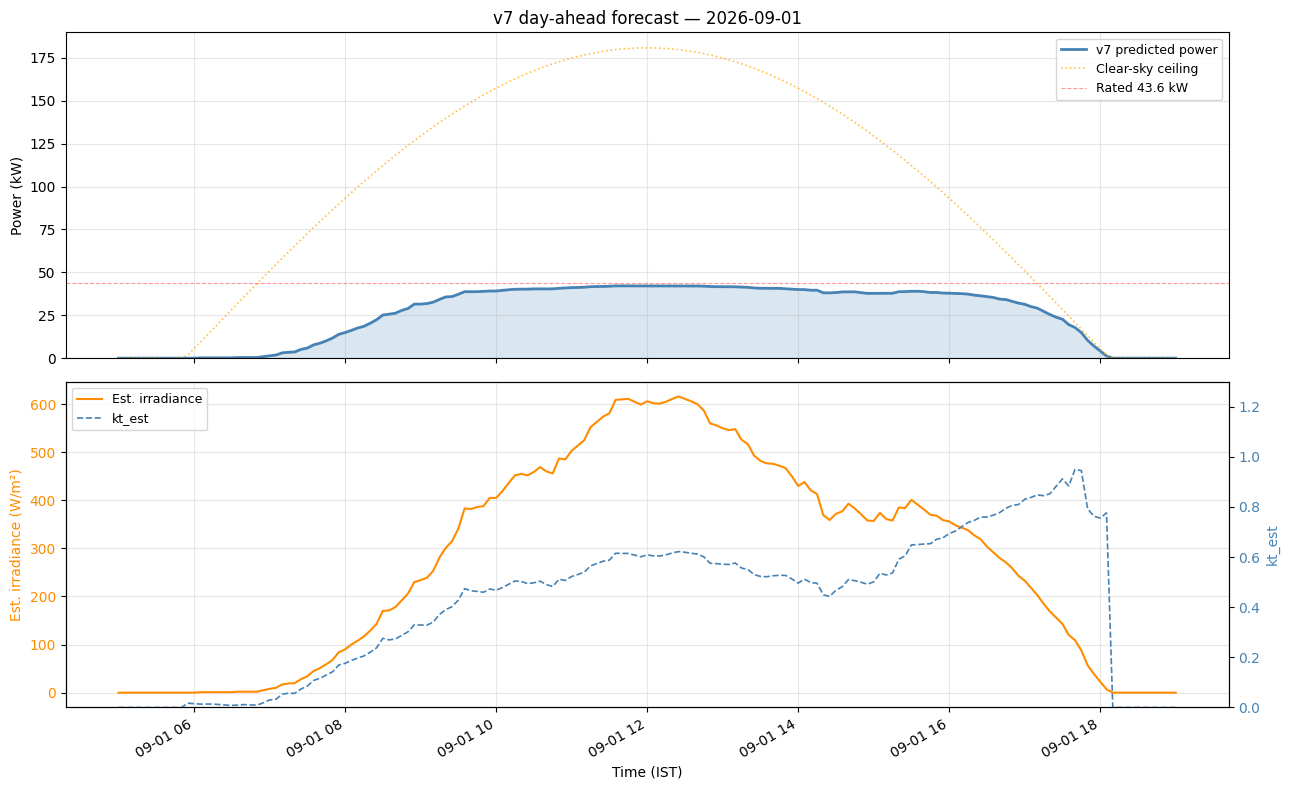

Peak power  : 42.13 kW
Total energy: 365.50 kWh


In [32]:
data_sep = [
    ("2026-09-01T00:00",25.4,92,13.4,0.1,88,7,29,77),
    ("2026-09-01T01:00",24.6,95,12.5,0.9,77,9,23,75),
    ("2026-09-01T02:00",24.4,96,11.2,0.9,67,6,16,63),
    ("2026-09-01T03:00",24.4,96,11.2,0.3,73,5,28,71),
    ("2026-09-01T04:00",24.5,95,10.6,0  ,63,5,13,55),
    ("2026-09-01T05:00",24.6,95,11.1,0  ,70,19,20,82),
    ("2026-09-01T06:00",26.1,91, 9.5,0  ,84,5,20,81),
    ("2026-09-01T07:00",26.9,90, 9.0,0  ,83,13,26,83),
    ("2026-09-01T08:00",27.5,87, 7.1,0  ,82,20,8,82),
    ("2026-09-01T09:00",28.8,79,10.1,0.5,83,21,11,82),
    ("2026-09-01T10:00",29.5,71,13.8,0  ,77,20,15,76),
    ("2026-09-01T11:00",28.9,72,18.4,0.1,82,16,26,81),
    ("2026-09-01T12:00",28.8,76,11.4,0.3,99,5,30,100),
    ("2026-09-01T13:00",29.2,74,12.5,0.2,98,22,13,96),
    ("2026-09-01T14:00",29.9,70,11.8,0  ,99,12,16,99),
    ("2026-09-01T15:00",30.8,66,10.0,0  ,97,9,17,96),
    ("2026-09-01T16:00",31.1,64,10.6,0  ,96,16,17,95),
    ("2026-09-01T17:00",30.4,68, 8.9,0  ,90,5,10,80),
    ("2026-09-01T18:00",28.5,84, 2.4,0  ,75,0,15,71),
    ("2026-09-01T19:00",27.8,86, 2.7,0  ,88,3,17,86),
    ("2026-09-01T20:00",27.4,87, 1.7,0.2,82,8,22,80),
    ("2026-09-01T21:00",27.2,87, 3.7,0  ,75,8,16,74),
    ("2026-09-01T22:00",27.2,87, 2.7,0  ,79,5,23,78),
    ("2026-09-01T23:00",26.8,85, 7.4,0  ,83,7,21,82),
    ("2026-09-02T00:00",26.3,86, 6.1,0  ,91,20,28,90),
]
sep_out = forecast_from_hourly("2026-09-01", data_sep)

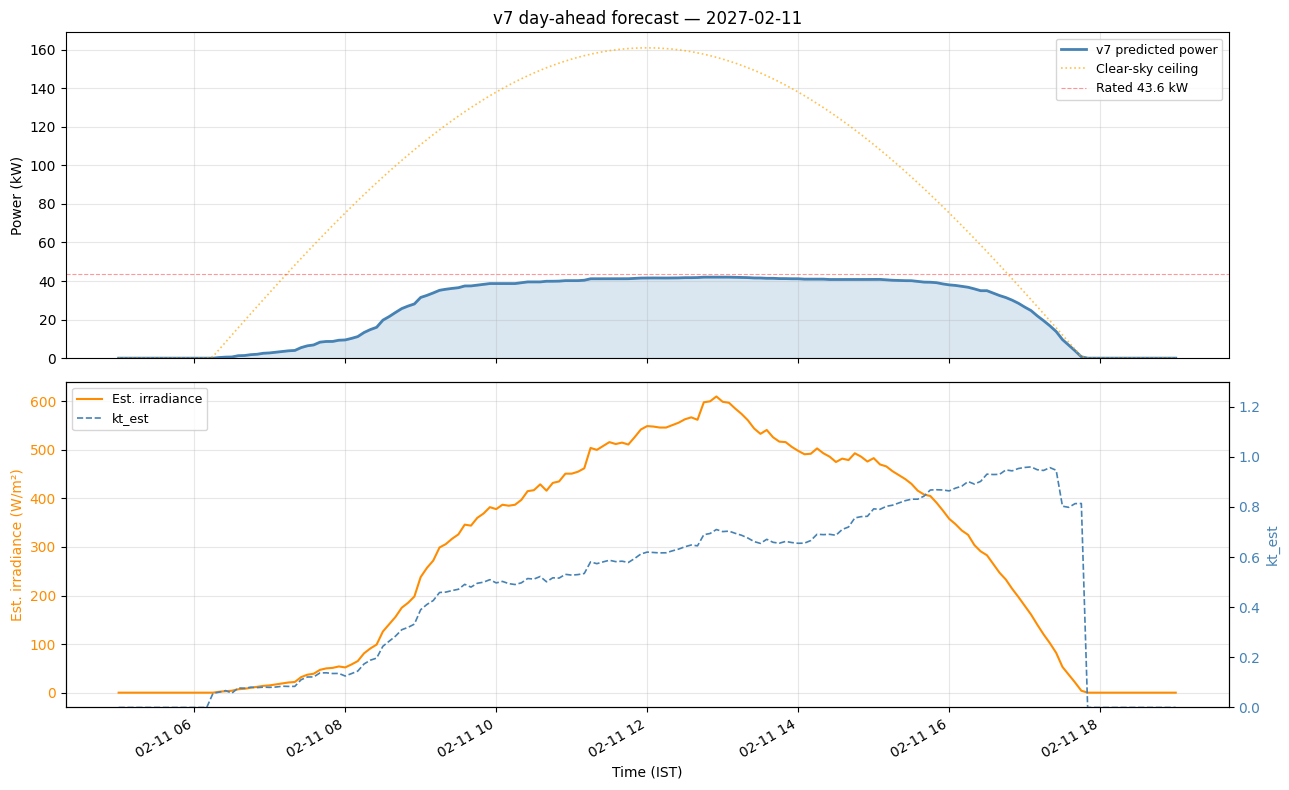

Peak power  : 42.01 kW
Total energy: 351.91 kWh


In [33]:
data_feb = [
    ("2027-02-10T23:00",28.1,80, 6.1,0  ,47,7,1,43),
    ("2027-02-11T00:00",27.8,81, 4.4,0  ,43,8,2,37),
    ("2027-02-11T01:00",27.5,82, 4.8,0.1,65,10,3,56),
    ("2027-02-11T02:00",27.5,82, 4.9,0  ,66,11,0,59),
    ("2027-02-11T03:00",26.9,85, 4.0,0  ,82,20,18,63),
    ("2027-02-11T04:00",26.5,88, 5.4,0  ,77,36,0,74),
    ("2027-02-11T05:00",26.5,89, 5.6,0.1,70,37,20,65),
    ("2027-02-11T06:00",27.5,83, 4.8,0  ,88,44,16,80),
    ("2027-02-11T07:00",28.5,77, 6.2,0.1,88,50,8,83),
    ("2027-02-11T08:00",29.5,73,10.2,0.1,73,31,3,59),
    ("2027-02-11T09:00",29.5,71,11.0,1.6,69,22,3,56),
    ("2027-02-11T10:00",29.3,73,10.2,0.4,63,19,13,38),
    ("2027-02-11T11:00",31.2,64,13.3,0  ,59,14,9,41),
    ("2027-02-11T12:00",31.5,64,13.7,0  ,64,10,6,51),
    ("2027-02-11T13:00",31.8,63,14.4,0  ,82,11,10,68),
    ("2027-02-11T14:00",31.5,64,15.2,0  ,60,5,4,54),
    ("2027-02-11T15:00",31.1,65,14.8,0  ,69,4,1,68),
    ("2027-02-11T16:00",30.2,70,14.9,0  ,61,3,2,61),
    ("2027-02-11T17:00",29.2,71,13.4,0  ,39,2,1,64),
    ("2027-02-11T18:00",28.1,78,11.3,0  ,61,4,3,59),
    ("2027-02-11T19:00",28.0,81, 8.9,0  ,62,5,4,57),
    ("2027-02-11T20:00",27.8,83, 7.6,0  ,52,6,4,45),
    ("2027-02-11T21:00",27.6,84, 5.7,0  ,52,15,0,37),
    ("2027-02-11T22:00",27.1,87, 4.4,0  ,52,16,0,43),
    ("2027-02-11T23:00",27.0,87, 5.4,0  ,59,16,0,48),
    ("2027-02-12T00:00",27.0,86, 5.5,0  ,71,25,0,49),
]
feb_out = forecast_from_hourly("2027-02-11", data_feb)


## 15. Save models and metadata

All artifacts go to `ART_DIR` (`C:\Solar_SUDHA_maam\models`). `v7_metadata.json` records the chronological train/validation/test split, validation metrics, and final untouched test metrics.


In [34]:
def _save(obj, name):
    path = os.path.join(ART_DIR, name)
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  Saved: {path} ({os.path.getsize(path)/1024:.1f} KB)")

print("Saving model pickles...")
_save(kt_model_v7,     "kt_model_v7.pkl")
_save(power_model_v7,  "power_model_v7.pkl")
_save(sensor_model_v7, "sensor_model_v7.pkl")

Saving model pickles...
  Saved: C:\Solar_SUDHA_maam\models\kt_model_v7.pkl (3432.4 KB)
  Saved: C:\Solar_SUDHA_maam\models\power_model_v7.pkl (101.0 KB)
  Saved: C:\Solar_SUDHA_maam\models\sensor_model_v7.pkl (497.3 KB)


In [36]:

metadata = {
    "version": "v7",
    "trained_at": datetime.utcnow().isoformat() + "Z",
    "split_policy": "chronological_train_validation_test",
    "xgboost_version": xgb.__version__,
    "use_gpu_requested": USE_GPU,
    "xgb_device": XGB_DEVICE,
    "gpu_probe_status": GPU_PROBE_STATUS,
    "xgb_base_params": XGB_BASE_PARAMS,
    "val_date": VAL_DATE,
    "test_date": TEST_DATE,
    "split_date": TEST_DATE,  # backward-compatible alias for older readers
    "solar_elev_min_deg": SOLAR_ELEV_MIN_DEG,
    "plant": {
        "latitude": LATITUDE,
        "area_eff": AREA_EFF,
        "rated_kw": RATED_KW,
    },
    "split_rows": {
        "train": int(len(train)),
        "validation": int(len(val_est)),
        "test": int(len(test)),
    },
    "monthly_maps": {
        "humidity": {int(k): float(v) for k, v in MONTHLY_HUM_MAP.items()},
        "temp":     {int(k): float(v) for k, v in MONTHLY_TEMP_MAP.items()},
    },
    "feature_lists": {
        "weather_feats":   WEATHER_FEATS,
        "features_sensor": FEATURES_SENSOR,
        "features_oracle": FEATURES_ORACLE,
    },
    "kt_model": {
        "best_params":  KT_BEST_PARAMS,
        "cv_r2":        KT_CV_R2,
        "train_r2":     float(KT_TRAIN_R2),
        "val_r2":       float(KT_VAL_R2),
        "test_r2":      float(KT_TEST_R2),
        "n_train_rows": int(len(kt_train)),
        "n_val_rows":   int(len(kt_val)),
        "n_test_rows":  int(len(kt_test)),
    },
    "power_model": {
        "best_params":  POWER_BEST_PARAMS,
        "cv_r2":        POWER_CV_R2,
        "n_train_rows": int(len(po_train)),
        "n_val_rows":   int(len(po_val)),
        "n_test_rows":  int(len(po_test)),
    },
    "sensor_model": {
        "best_params":  SENSOR_BEST_PARAMS,
        "cv_r2":        SENSOR_CV_R2,
        "n_train_rows": int(len(se_train)),
        "n_val_rows":   int(len(se_val)),
        "n_test_rows":  int(len(se_test)),
    },
    "validation_metrics": {
        "oracle_all_r2":     float(VALIDATION_METRICS["oracle_all_r2"]),
        "oracle_all_mae_kw": float(VALIDATION_METRICS["oracle_all_mae"]),
        "oracle_day_r2":     float(VALIDATION_METRICS["oracle_day_r2"]),
        "oracle_day_mae_kw": float(VALIDATION_METRICS["oracle_day_mae"]),
        "sensor_all_r2":     float(VALIDATION_METRICS["sensor_all_r2"]),
        "sensor_all_mae_kw": float(VALIDATION_METRICS["sensor_all_mae"]),
        "sensor_day_r2":     float(VALIDATION_METRICS["sensor_day_r2"]),
        "sensor_day_mae_kw": float(VALIDATION_METRICS["sensor_day_mae"]),
    },
    "test_metrics": {
        "oracle_all_r2":     float(HEADLINE_METRICS["oracle_all_r2"]),
        "oracle_all_mae_kw": float(HEADLINE_METRICS["oracle_all_mae"]),
        "oracle_day_r2":     float(HEADLINE_METRICS["oracle_day_r2"]),
        "oracle_day_mae_kw": float(HEADLINE_METRICS["oracle_day_mae"]),
        "sensor_all_r2":     float(HEADLINE_METRICS["sensor_all_r2"]),
        "sensor_all_mae_kw": float(HEADLINE_METRICS["sensor_all_mae"]),
        "sensor_day_r2":     float(HEADLINE_METRICS["sensor_day_r2"]),
        "sensor_day_mae_kw": float(HEADLINE_METRICS["sensor_day_mae"]),
        "worst_month_oracle_r2": float(WORST_MONTH_ORACLE_R2),
    },
    "v6_baseline_for_comparison": V6,
}

meta_path = os.path.join(ART_DIR, "v7_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"\nSaved metadata: {meta_path} ({os.path.getsize(meta_path)/1024:.1f} KB)")



Saved metadata: C:\Solar_SUDHA_maam\models\v7_metadata.json (7.4 KB)


In [37]:
# Final verification — all artifacts present and metadata roundtrips
artifacts = ["kt_model_v7.pkl", "power_model_v7.pkl",
             "sensor_model_v7.pkl", "v7_metadata.json"]
for name in artifacts:
    p = os.path.join(ART_DIR, name)
    assert os.path.exists(p), f"MISSING: {p}"
    assert os.path.getsize(p) > 0, f"EMPTY: {p}"
with open(os.path.join(ART_DIR, "v7_metadata.json")) as f:
    meta = json.load(f)
assert meta["version"] == "v7"
assert "kt_model" in meta and "power_model" in meta and "sensor_model" in meta
assert len(meta["feature_lists"]["weather_feats"]) == 36
print("OK: all 4 artifacts present, non-empty, metadata.json roundtrips and has 36 weather feats.")
print(f"\nv7 artifacts complete in {ART_DIR}")

OK: all 4 artifacts present, non-empty, metadata.json roundtrips and has 36 weather feats.

v7 artifacts complete in C:\Solar_SUDHA_maam\models


## 16. Comprehensive analytical comparison

Single cell producing seven analytical views suitable for paper figures:

1. **Predicted vs Actual scatter** (oracle + sensor) — regression analog of confusion matrix
2. **Residual distribution** — error shape, bias visibility
3. **Residual vs Prediction** — heteroscedasticity check
4. **Feature correlation matrix** — for the unified feature set
5. **Top-15 feature importance** — for oracle and sensor models
6. **Per-hour-of-day MAE** — when does each model struggle
7. **Per-month MAE bar chart** — seasonal stability


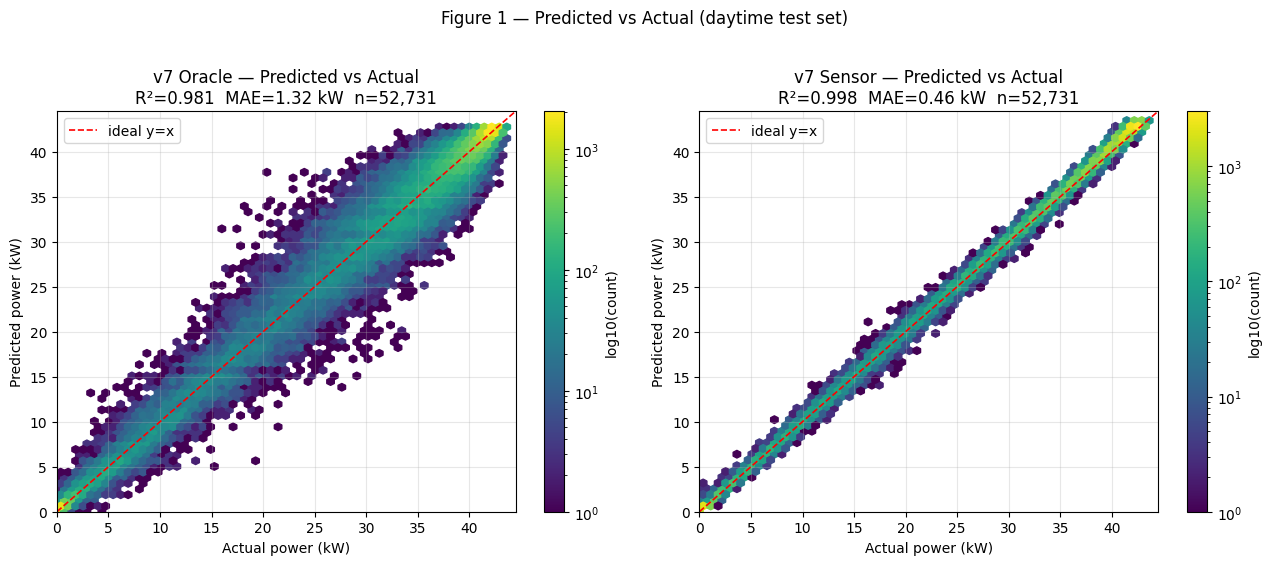

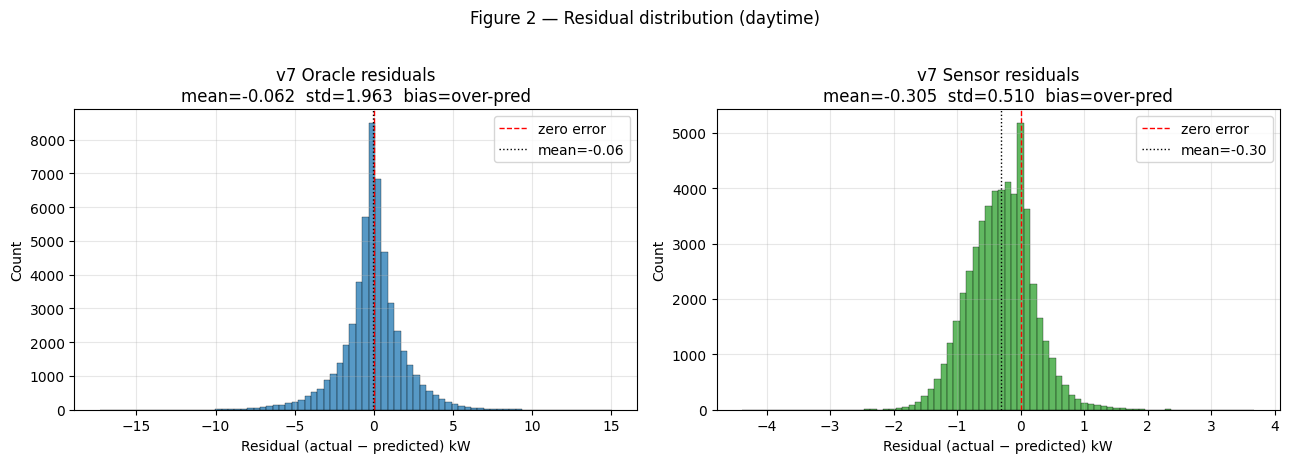

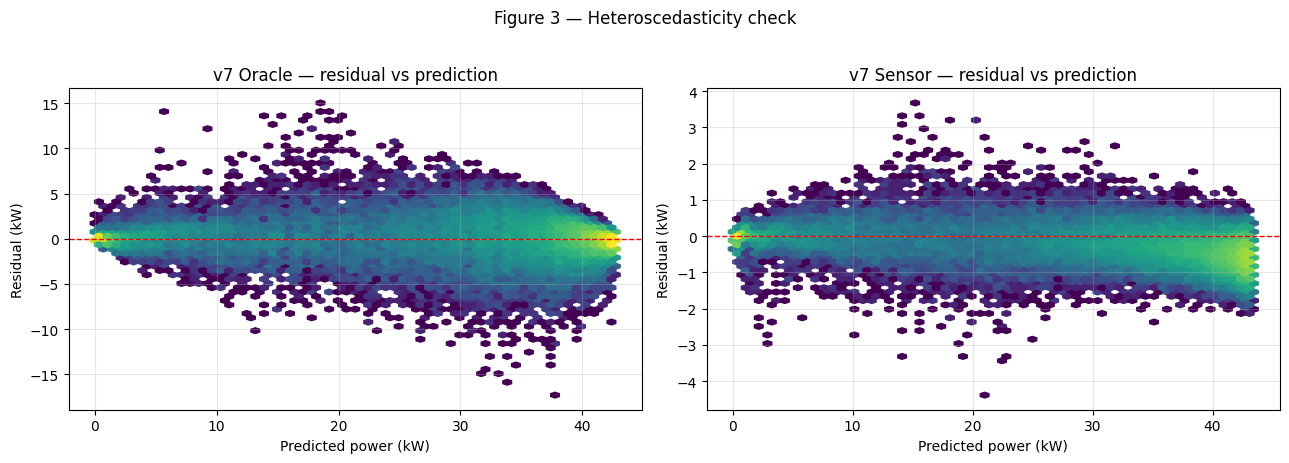

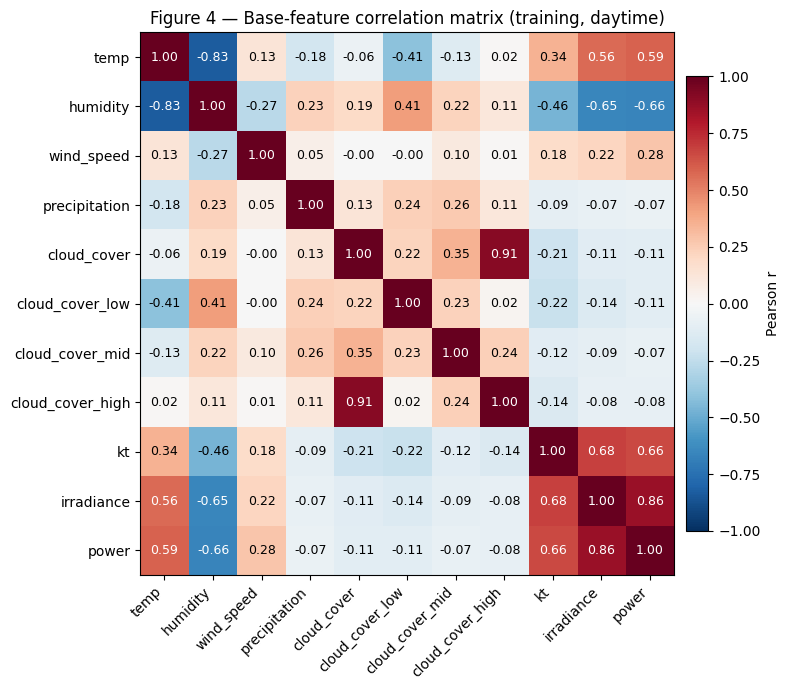

Top 8 |corr| with power:
humidity            0.661501
temp                0.585986
wind_speed          0.275856
cloud_cover_low     0.108518
cloud_cover         0.106266
cloud_cover_high    0.079716
cloud_cover_mid     0.073530
precipitation       0.066681

Top 8 |corr| with kt:
humidity            0.462130
temp                0.344980
cloud_cover_low     0.219054
cloud_cover         0.206110
wind_speed          0.184750
cloud_cover_high    0.144097
cloud_cover_mid     0.115540
precipitation       0.090308


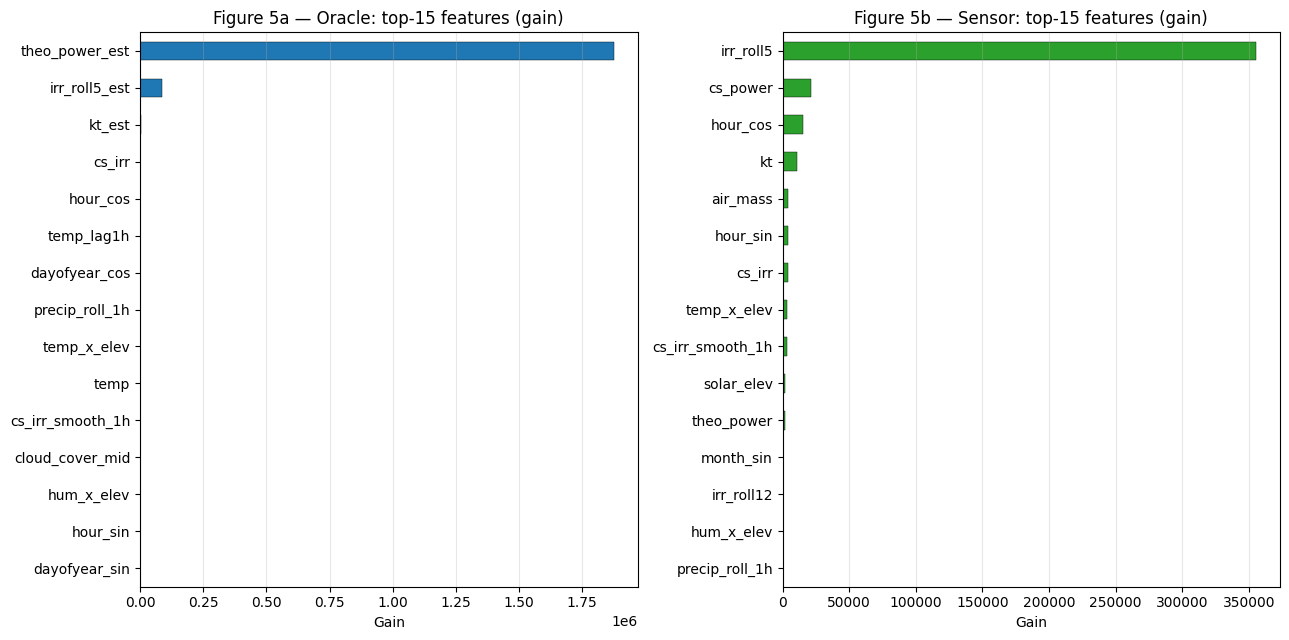

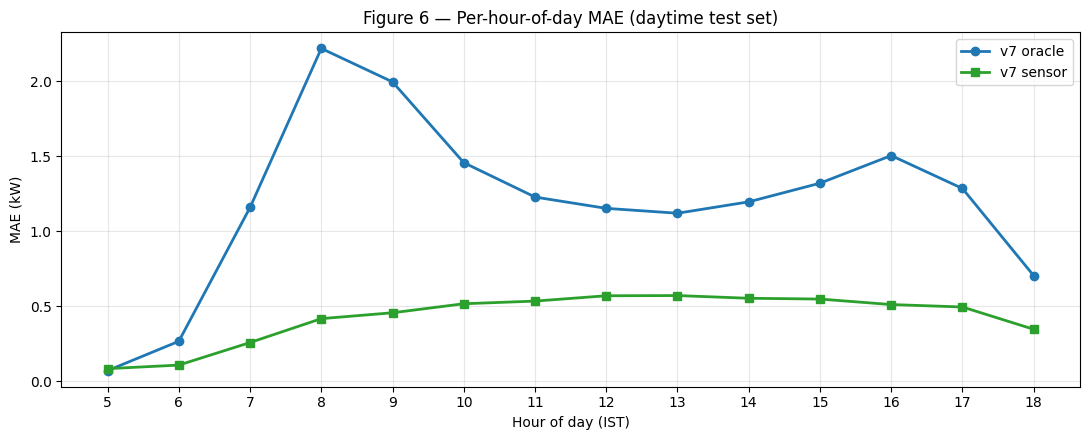

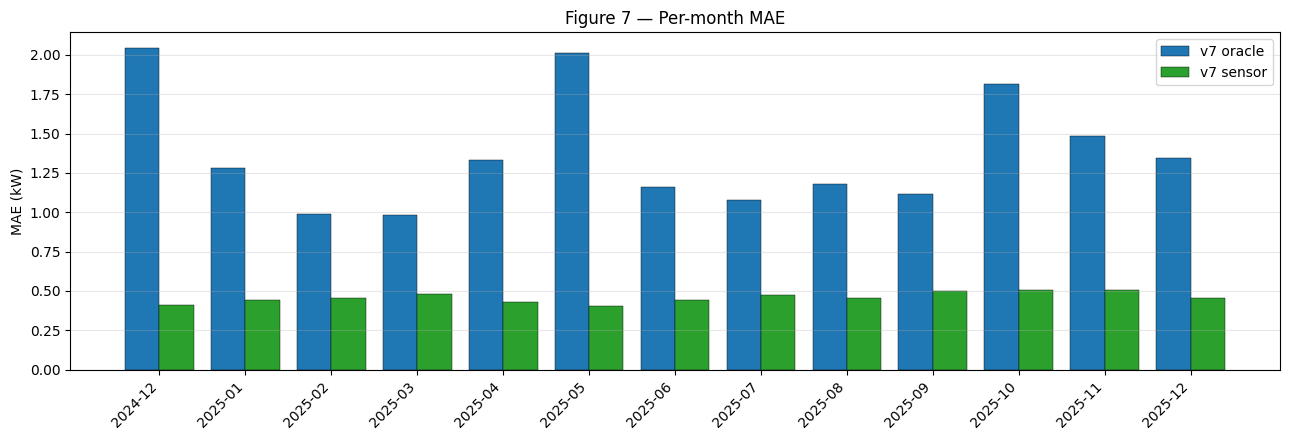


Comparison summary
Metric                                  Oracle        Sensor
R² (daytime)                            0.9811        0.9983
MAE kW (daytime)                        1.3249        0.4620
Residual mean kW                       -0.0618       -0.3047
Residual std  kW                        1.9630        0.5102
Worst hour MAE kW                       2.2173        0.5706
Worst hour                                   8            13
Worst month MAE kW                      2.0417        0.5062
Worst month                            2024-12       2025-11


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

# ---------------------------------------------------------------------------
# Pull daytime predictions and actuals for both models
# ---------------------------------------------------------------------------
day_o_mask = (po_test["cs_irr"] > 10).values
day_s_mask = (se_test["cs_irr"] > 10).values

y_true_o = po_test.loc[day_o_mask, "power"].values
y_pred_o = po_test.loc[day_o_mask, "pred_oracle"].values
y_true_s = se_test.loc[day_s_mask, "power"].values
y_pred_s = se_test.loc[day_s_mask, "pred_sensor"].values

resid_o = y_true_o - y_pred_o
resid_s = y_true_s - y_pred_s

# ---------------------------------------------------------------------------
# Figure 1 — Predicted vs Actual (oracle | sensor)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, y_t, y_p, name, c in [
    (axes[0], y_true_o, y_pred_o, "Oracle", "tab:blue"),
    (axes[1], y_true_s, y_pred_s, "Sensor", "tab:green"),
]:
    hb = ax.hexbin(y_t, y_p, gridsize=60, cmap="viridis", bins="log", mincnt=1)
    lim = max(y_t.max(), y_p.max()) * 1.02
    ax.plot([0, lim], [0, lim], color="red", lw=1.2, ls="--", label="ideal y=x")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual power (kW)")
    ax.set_ylabel("Predicted power (kW)")
    r2 = r2_score(y_t, y_p); mae = mean_absolute_error(y_t, y_p)
    ax.set_title(f"v7 {name} — Predicted vs Actual\nR²={r2:.3f}  MAE={mae:.2f} kW  n={len(y_t):,}")
    ax.grid(alpha=0.3); ax.legend(loc="upper left")
    plt.colorbar(hb, ax=ax, label="log10(count)")

plt.suptitle("Figure 1 — Predicted vs Actual (daytime test set)", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 2 — Residual distribution
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, r, name, c in [
    (axes[0], resid_o, "Oracle", "tab:blue"),
    (axes[1], resid_s, "Sensor", "tab:green"),
]:
    ax.hist(r, bins=80, color=c, alpha=0.75, edgecolor="black", linewidth=0.3)
    ax.axvline(0, color="red", lw=1, ls="--", label="zero error")
    ax.axvline(r.mean(), color="black", lw=1, ls=":", label=f"mean={r.mean():.2f}")
    ax.set_xlabel("Residual (actual − predicted) kW")
    ax.set_ylabel("Count")
    bias_dir = "over" if r.mean() < 0 else "under"
    ax.set_title(f"v7 {name} residuals\nmean={r.mean():.3f}  std={r.std():.3f}  bias={bias_dir}-pred")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Figure 2 — Residual distribution (daytime)", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 3 — Residual vs Prediction (heteroscedasticity)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, y_p, r, name, c in [
    (axes[0], y_pred_o, resid_o, "Oracle", "tab:blue"),
    (axes[1], y_pred_s, resid_s, "Sensor", "tab:green"),
]:
    ax.hexbin(y_p, r, gridsize=60, cmap="viridis", bins="log", mincnt=1)
    ax.axhline(0, color="red", lw=1, ls="--")
    ax.set_xlabel("Predicted power (kW)")
    ax.set_ylabel("Residual (kW)")
    ax.set_title(f"v7 {name} — residual vs prediction")
    ax.grid(alpha=0.3)
plt.suptitle("Figure 3 — Heteroscedasticity check", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 4 — Feature correlation matrix (training set, daytime)
# ---------------------------------------------------------------------------
# Only the raw weather inputs that come from the dataset (no derived/engineered features).
BASE_FEATS = ["temp", "humidity", "wind_speed", "precipitation",
              "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high"]
corr_feats = BASE_FEATS + ["kt", "irradiance", "power"]
corr_df = train.loc[train["cs_irr"] > 10, corr_feats].copy()
corr_df = corr_df.replace([np.inf, -np.inf], np.nan).dropna()
corr_mat = corr_df.corr().values

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_mat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_feats))); ax.set_yticks(range(len(corr_feats)))
ax.set_xticklabels(corr_feats, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(corr_feats, fontsize=10)
for i in range(len(corr_feats)):
    for j in range(len(corr_feats)):
        v = corr_mat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="Pearson r")
ax.set_title("Figure 4 — Base-feature correlation matrix (training, daytime)")
plt.tight_layout(); plt.show()

power_corr = corr_df.corr()["power"].drop(["power", "irradiance", "kt"]).abs().sort_values(ascending=False)
kt_corr    = corr_df.corr()["kt"].drop(["kt", "irradiance", "power"]).abs().sort_values(ascending=False)
print("Top 8 |corr| with power:"); print(power_corr.head(8).to_string())
print("\nTop 8 |corr| with kt:"); print(kt_corr.head(8).to_string())

# ---------------------------------------------------------------------------
# Figure 5 — Top-15 feature importance
# ---------------------------------------------------------------------------
def topk_importance(model, feature_names, k=15):
    booster = model.get_booster()
    raw = booster.get_score(importance_type="gain")
    name_map = {f"f{i}": n for i, n in enumerate(feature_names)}
    imp = {(name_map.get(k_, k_)): v for k_, v in raw.items()}
    series = pd.Series(imp).sort_values(ascending=False).head(k)
    return series

imp_oracle = topk_importance(power_model_v7,  FEATURES_ORACLE, k=15)
imp_sensor = topk_importance(sensor_model_v7, FEATURES_SENSOR, k=15)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
imp_oracle[::-1].plot(kind="barh", ax=axes[0], color="tab:blue", edgecolor="black", linewidth=0.3)
axes[0].set_title("Figure 5a — Oracle: top-15 features (gain)")
axes[0].set_xlabel("Gain"); axes[0].grid(axis="x", alpha=0.3)

imp_sensor[::-1].plot(kind="barh", ax=axes[1], color="tab:green", edgecolor="black", linewidth=0.3)
axes[1].set_title("Figure 5b — Sensor: top-15 features (gain)")
axes[1].set_xlabel("Gain"); axes[1].grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 6 — Per-hour-of-day MAE
# ---------------------------------------------------------------------------
po_day = po_test[day_o_mask].copy()
po_day["abs_err"] = np.abs(po_day["power"] - po_day["pred_oracle"])
po_day["hour_int"] = po_day["time"].dt.hour
hourly_o = po_day.groupby("hour_int")["abs_err"].mean()

se_day = se_test[day_s_mask].copy()
se_day["abs_err"] = np.abs(se_day["power"] - se_day["pred_sensor"])
se_day["hour_int"] = se_day["time"].dt.hour
hourly_s = se_day.groupby("hour_int")["abs_err"].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hourly_o.index, hourly_o.values, "-o", color="tab:blue",  lw=2, label="v7 oracle")
ax.plot(hourly_s.index, hourly_s.values, "-s", color="tab:green", lw=2, label="v7 sensor")
ax.set_xlabel("Hour of day (IST)")
ax.set_ylabel("MAE (kW)")
ax.set_title("Figure 6 — Per-hour-of-day MAE (daytime test set)")
ax.set_xticks(range(int(min(hourly_o.index.min(), hourly_s.index.min())),
                    int(max(hourly_o.index.max(), hourly_s.index.max())) + 1))
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 7 — Per-month MAE bar chart (oracle vs sensor)
# ---------------------------------------------------------------------------
po_day["month_name"] = po_day["time"].dt.strftime("%Y-%m")
se_day["month_name"] = se_day["time"].dt.strftime("%Y-%m")
mae_o_by_month = po_day.groupby("month_name")["abs_err"].mean()
mae_s_by_month = se_day.groupby("month_name")["abs_err"].mean()
months = sorted(set(mae_o_by_month.index) & set(mae_s_by_month.index))
x = np.arange(len(months))
width = 0.4

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - width/2, [mae_o_by_month[m] for m in months], width,
       color="tab:blue",  edgecolor="black", linewidth=0.3, label="v7 oracle")
ax.bar(x + width/2, [mae_s_by_month[m] for m in months], width,
       color="tab:green", edgecolor="black", linewidth=0.3, label="v7 sensor")
ax.set_xticks(x); ax.set_xticklabels(months, rotation=45, ha="right")
ax.set_ylabel("MAE (kW)")
ax.set_title("Figure 7 — Per-month MAE")
ax.grid(axis="y", alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Summary print
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("Comparison summary")
print("=" * 70)
print(f"{'Metric':<32}{'Oracle':>14}{'Sensor':>14}")
print(f"{'R² (daytime)':<32}{r2_score(y_true_o, y_pred_o):>14.4f}{r2_score(y_true_s, y_pred_s):>14.4f}")
print(f"{'MAE kW (daytime)':<32}{mean_absolute_error(y_true_o, y_pred_o):>14.4f}{mean_absolute_error(y_true_s, y_pred_s):>14.4f}")
print(f"{'Residual mean kW':<32}{resid_o.mean():>14.4f}{resid_s.mean():>14.4f}")
print(f"{'Residual std  kW':<32}{resid_o.std():>14.4f}{resid_s.std():>14.4f}")
print(f"{'Worst hour MAE kW':<32}{hourly_o.max():>14.4f}{hourly_s.max():>14.4f}")
print(f"{'Worst hour':<32}{int(hourly_o.idxmax()):>14d}{int(hourly_s.idxmax()):>14d}")
print(f"{'Worst month MAE kW':<32}{mae_o_by_month.max():>14.4f}{mae_s_by_month.max():>14.4f}")
print(f"{'Worst month':<32}{mae_o_by_month.idxmax():>14}{mae_s_by_month.idxmax():>14}")


## 17. Time-aggregated forecasts and final metrics

Operational view of the v7 forecasts at four cadences:
1. **Hour-of-day average power** — diurnal shape recovery (actual vs oracle vs sensor)
2. **Daily totals** — full-day energy (kWh/day) over the test set
3. **Weekly rolling average** — 7-day smoothed power, shows seasonal drift
4. **Monthly average daytime power** — climate-scale comparison

Closes with a single summary table of all headline metrics.


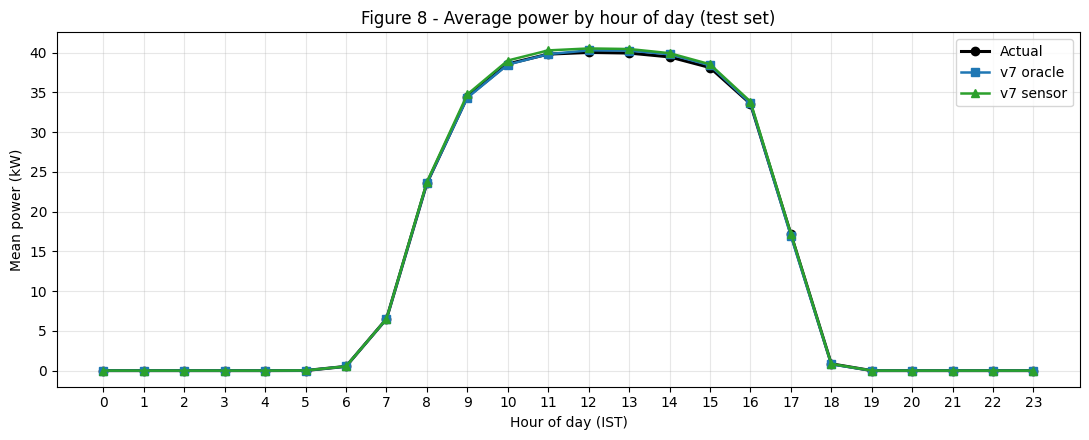

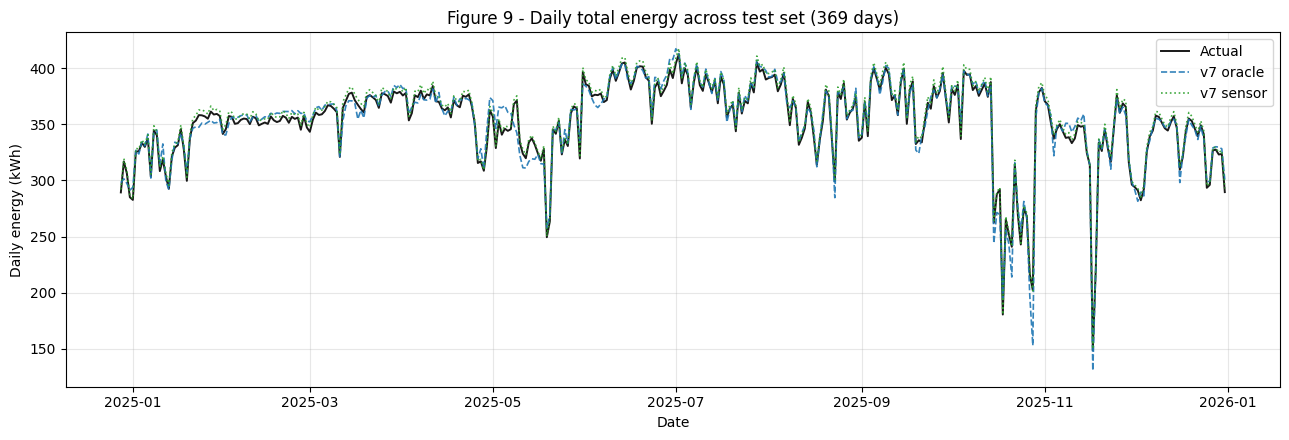

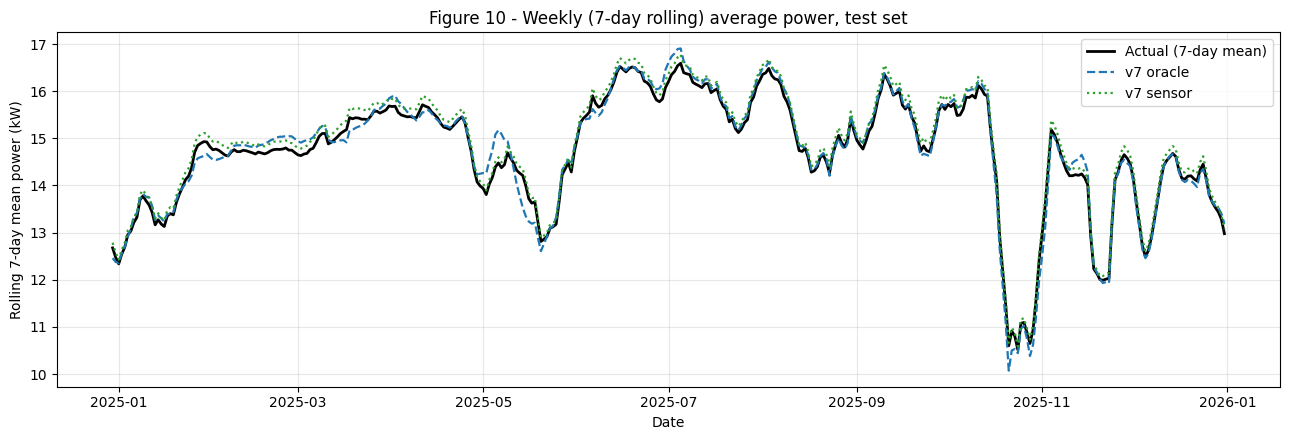

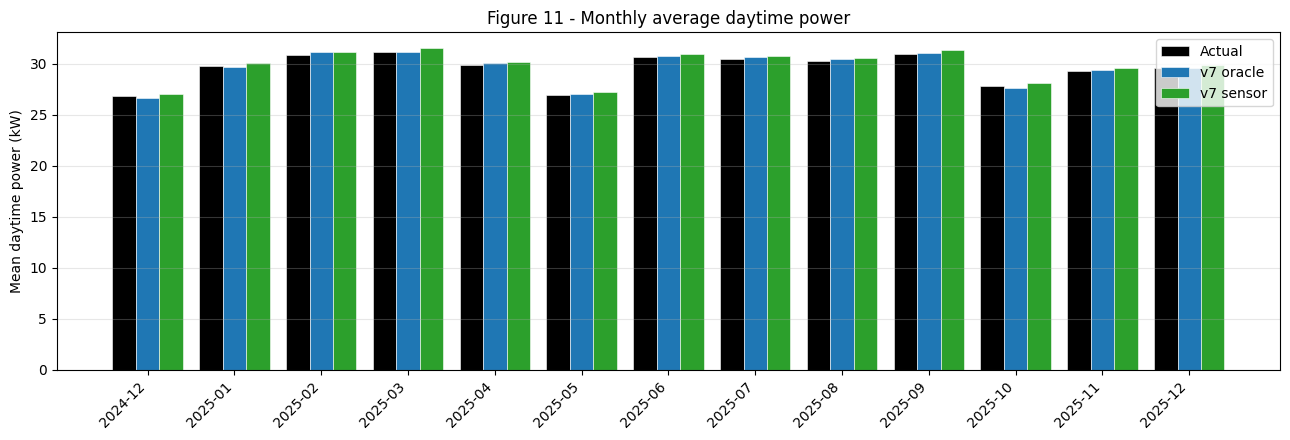

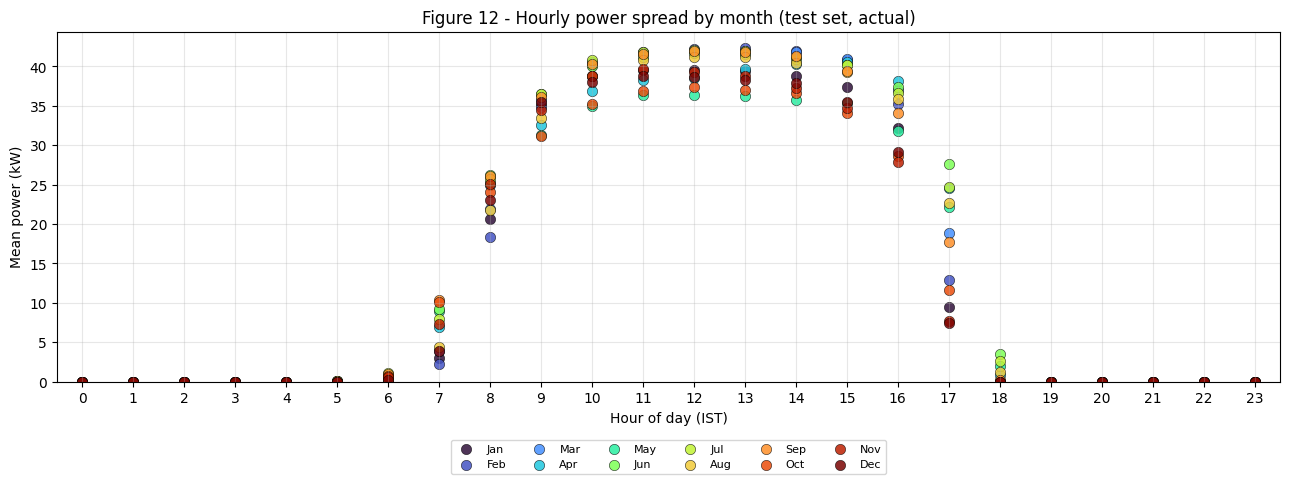

FINAL METRICS - v7 daytime test set
Metric                          Oracle              Sensor
------------------------------------------------------------------
R2                              0.9811              0.9983
MAE (kW)                        1.3249              0.4620
RMSE (kW)                       1.9640              0.5943
Bias (kW)                       0.0618              0.3047
MAPE (%)                       12.5112              5.9275
n                               52,731              52,731

Daily-energy errors (kWh/day):
Metric                          Oracle              Sensor
------------------------------------------------------------------
MAE (kWh)                         5.22                3.62
MAPE (%)                          1.59                1.01
mean actual                     352.77              352.77


In [39]:
# Time-aggregated forecast diagnostics
# Uses po_test (oracle predictions) and se_test (sensor predictions),
# both already populated by section 11 of this notebook.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Build a single dataframe of test-set actuals + both predictions
agg = pd.DataFrame({
    "time":        po_test["time"].values,
    "actual":      po_test["power"].values,
    "pred_oracle": po_test["pred_oracle"].values,
    "pred_sensor": se_test["pred_sensor"].values,
})
agg["time"] = pd.to_datetime(agg["time"])
agg = agg.sort_values("time").reset_index(drop=True)

agg["hour_int"] = agg["time"].dt.hour
agg["date"]     = agg["time"].dt.normalize()
agg["yrmonth"]  = agg["time"].dt.to_period("M").dt.start_time

# ---------------------------------------------------------------------------
# Figure 8 - Hour-of-day average power (diurnal shape)
# ---------------------------------------------------------------------------
hod = agg.groupby("hour_int").agg(actual=("actual", "mean"),
                                  oracle=("pred_oracle", "mean"),
                                  sensor=("pred_sensor", "mean"))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hod.index, hod["actual"], "-o", color="black",     lw=2.2, label="Actual")
ax.plot(hod.index, hod["oracle"], "-s", color="tab:blue",  lw=1.8, label="v7 oracle")
ax.plot(hod.index, hod["sensor"], "-^", color="tab:green", lw=1.8, label="v7 sensor")
ax.set_xlabel("Hour of day (IST)")
ax.set_ylabel("Mean power (kW)")
ax.set_title("Figure 8 - Average power by hour of day (test set)")
ax.set_xticks(range(0, 24))
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 9 - Daily total energy (kWh/day)
# 5-min cadence -> each row contributes (power kW) * (5/60 h) kWh
# ---------------------------------------------------------------------------
daily = agg.groupby("date").agg(actual=("actual", "sum"),
                                oracle=("pred_oracle", "sum"),
                                sensor=("pred_sensor", "sum")) * (5.0 / 60.0)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily["actual"], "-",  color="black",     lw=1.4, alpha=0.9, label="Actual")
ax.plot(daily.index, daily["oracle"], "--", color="tab:blue",  lw=1.2, alpha=0.9, label="v7 oracle")
ax.plot(daily.index, daily["sensor"], ":",  color="tab:green", lw=1.2, alpha=0.9, label="v7 sensor")
ax.set_xlabel("Date")
ax.set_ylabel("Daily energy (kWh)")
ax.set_title(f"Figure 9 - Daily total energy across test set ({len(daily):,} days)")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 10 - 7-day rolling average power
# ---------------------------------------------------------------------------
daily_mean = agg.groupby("date").agg(actual=("actual", "mean"),
                                     oracle=("pred_oracle", "mean"),
                                     sensor=("pred_sensor", "mean"))
roll7 = daily_mean.rolling(7, min_periods=3).mean()
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(roll7.index, roll7["actual"], "-",  color="black",     lw=2.0, label="Actual (7-day mean)")
ax.plot(roll7.index, roll7["oracle"], "--", color="tab:blue",  lw=1.6, label="v7 oracle")
ax.plot(roll7.index, roll7["sensor"], ":",  color="tab:green", lw=1.6, label="v7 sensor")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling 7-day mean power (kW)")
ax.set_title("Figure 10 - Weekly (7-day rolling) average power, test set")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 11 - Monthly average daytime power
# ---------------------------------------------------------------------------
day_only = agg[(agg["actual"] > 0.05) | (agg["pred_oracle"] > 0.05)].copy()
monthly = day_only.groupby("yrmonth").agg(actual=("actual", "mean"),
                                          oracle=("pred_oracle", "mean"),
                                          sensor=("pred_sensor", "mean"))
x = np.arange(len(monthly))
width = 0.27
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - width, monthly["actual"], width, color="black",     edgecolor="white", linewidth=0.4, label="Actual")
ax.bar(x,         monthly["oracle"], width, color="tab:blue",  edgecolor="white", linewidth=0.4, label="v7 oracle")
ax.bar(x + width, monthly["sensor"], width, color="tab:green", edgecolor="white", linewidth=0.4, label="v7 sensor")
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly.index], rotation=45, ha="right")
ax.set_ylabel("Mean daytime power (kW)")
ax.set_title("Figure 11 - Monthly average daytime power")
ax.grid(axis="y", alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Figure 12 - Hourly power spread by month (one dot per (month, hour))
# x axis: 0..23 hours of day (IST)
# y axis: mean power for that (month, hour) bucket
# colour: month (Jan..Dec)
# Shows the diurnal envelope and how it widens / narrows across seasons.
# ---------------------------------------------------------------------------
agg["month_int"] = agg["time"].dt.month
spread = (agg.groupby(["month_int", "hour_int"])
              .agg(actual=("actual", "mean"),
                   oracle=("pred_oracle", "mean"))
              .reset_index())

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
cmap = plt.get_cmap("turbo", 12)

fig, ax = plt.subplots(figsize=(13, 5))
for m in range(1, 13):
    sub = spread[spread["month_int"] == m]
    if sub.empty:
        continue
    ax.scatter(sub["hour_int"], sub["actual"],
               s=55, color=cmap(m-1), edgecolor="black", linewidth=0.4,
               alpha=0.85, label=month_names[m-1])

ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day (IST)")
ax.set_ylabel("Mean power (kW)")
ax.set_title("Figure 12 - Hourly power spread by month (test set, actual)")
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend(ncol=6, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# Final summary metrics (daytime only)
# ---------------------------------------------------------------------------
day_mask_o = (po_test["cs_irr"] > 10).values
day_mask_s = (se_test["cs_irr"] > 10).values
y_o = po_test.loc[day_mask_o, "power"].values
p_o = po_test.loc[day_mask_o, "pred_oracle"].values
y_s = se_test.loc[day_mask_s, "power"].values
p_s = se_test.loc[day_mask_s, "pred_sensor"].values

def _metrics(y, p):
    return {
        "R2":         r2_score(y, p),
        "MAE (kW)":   mean_absolute_error(y, p),
        "RMSE (kW)":  float(np.sqrt(mean_squared_error(y, p))),
        "Bias (kW)":  float(np.mean(p - y)),
        "MAPE (%)":   float(100 * np.mean(np.abs(p - y) / np.maximum(y, 0.1))),
        "n":          int(len(y)),
    }

m_oracle = _metrics(y_o, p_o)
m_sensor = _metrics(y_s, p_s)

print("=" * 66)
print("FINAL METRICS - v7 daytime test set")
print("=" * 66)
print(f"{'Metric':<18}{'Oracle':>20}{'Sensor':>20}")
print("-" * 66)
for k in m_oracle:
    if isinstance(m_oracle[k], int):
        print(f"{k:<18}{m_oracle[k]:>20,d}{m_sensor[k]:>20,d}")
    else:
        print(f"{k:<18}{m_oracle[k]:>20.4f}{m_sensor[k]:>20.4f}")

# Daily energy errors
de_mae_o  = float(np.mean(np.abs(daily["actual"] - daily["oracle"])))
de_mae_s  = float(np.mean(np.abs(daily["actual"] - daily["sensor"])))
de_mape_o = float(100 * np.mean(np.abs(daily["actual"] - daily["oracle"]) / np.maximum(daily["actual"], 1)))
de_mape_s = float(100 * np.mean(np.abs(daily["actual"] - daily["sensor"]) / np.maximum(daily["actual"], 1)))

print("\nDaily-energy errors (kWh/day):")
print(f"{'Metric':<18}{'Oracle':>20}{'Sensor':>20}")
print("-" * 66)
print(f"{'MAE (kWh)':<18}{de_mae_o:>20.2f}{de_mae_s:>20.2f}")
print(f"{'MAPE (%)':<18}{de_mape_o:>20.2f}{de_mape_s:>20.2f}")
print(f"{'mean actual':<18}{daily['actual'].mean():>20.2f}{daily['actual'].mean():>20.2f}")


## 17b. Extended evaluation metrics (publication-grade)

Adds the metrics solar-forecasting reviewers expect on top of the headline
R²/MAE/RMSE table in cell 54:

- **nRMSE / nMAE** — RMSE and MAE normalised by rated capacity (% of `RATED_KW`).
  Lets the result be compared against papers reporting on different plant sizes.
- **Forecast Skill Score** — `1 - RMSE_model / RMSE_persistence` against a
  24-hour persistence baseline (yesterday-same-time). > 0 means we beat
  persistence; this is the gold-standard skill metric for solar forecasting.
- **Pearson r** — linear correlation, complements R² (r is not penalised by
  systematic bias).
- **NSE (Nash-Sutcliffe Efficiency)** — variance-explained measure, common in
  energy/hydrology benchmarks.
- **Per-sky-condition MAE** — daytime errors split by clear / partly cloudy /
  overcast bins (cloud_cover thresholds: <30, 30-70, >70). Reveals whether
  the model fails on cloudy days.
- **Capacity Factor (CF)** — actual vs predicted average plant utilisation
  over the test set, expressed as a fraction of `RATED_KW`.


EXTENDED METRICS - v7 daytime test set (cs_irr > 10)
Metric                                Oracle              Sensor
----------------------------------------------------------------------
RMSE (kW)                             1.9640              0.5943
nRMSE (% rated)                       4.5020              1.3622
MAE (kW)                              1.3249              0.4620
nMAE (% rated)                        3.0371              1.0590
Bias (kW)                             0.0618              0.3047
Pearson r                             0.9906              0.9995
NSE                                   0.9811              0.9983
Skill vs persistence                  0.5163              0.8535
----------------------------------------------------------------------
Persistence RMSE (kW)   = 4.0762   (24-hour lag baseline)

Per-sky-condition errors (oracle, daytime):
                       n  MAE (kW)  RMSE (kW)  mean actual  mean pred
sky                                            

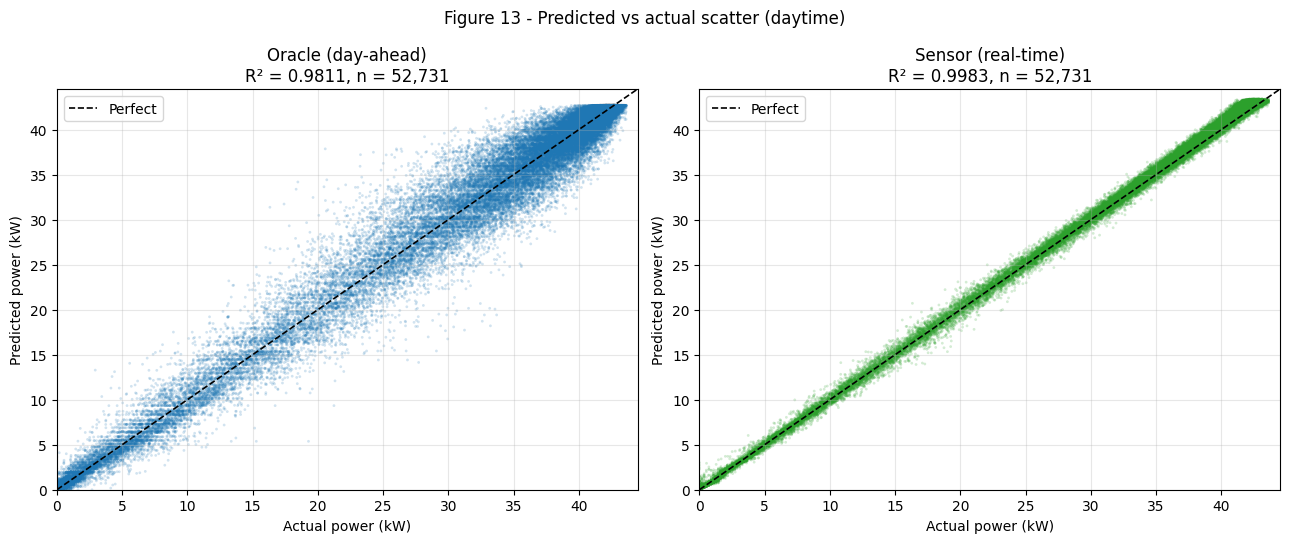

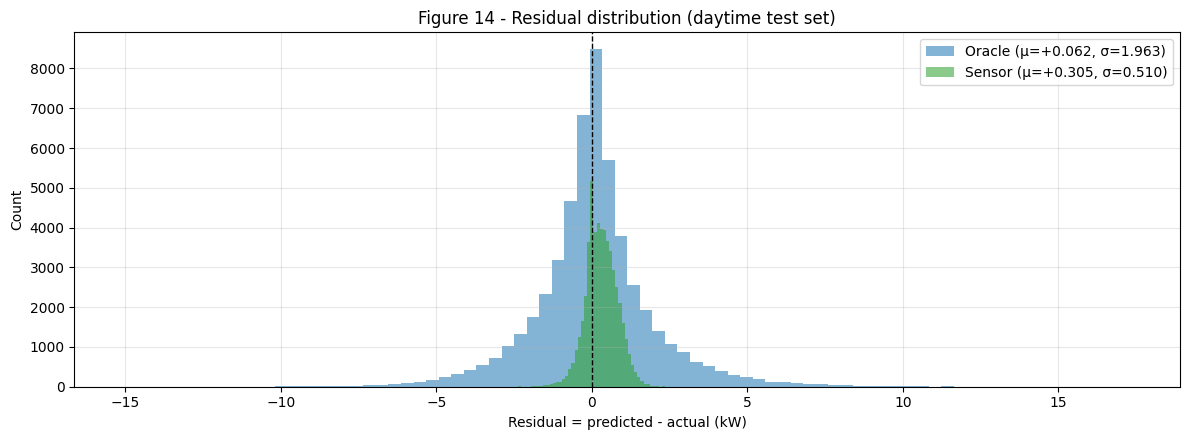

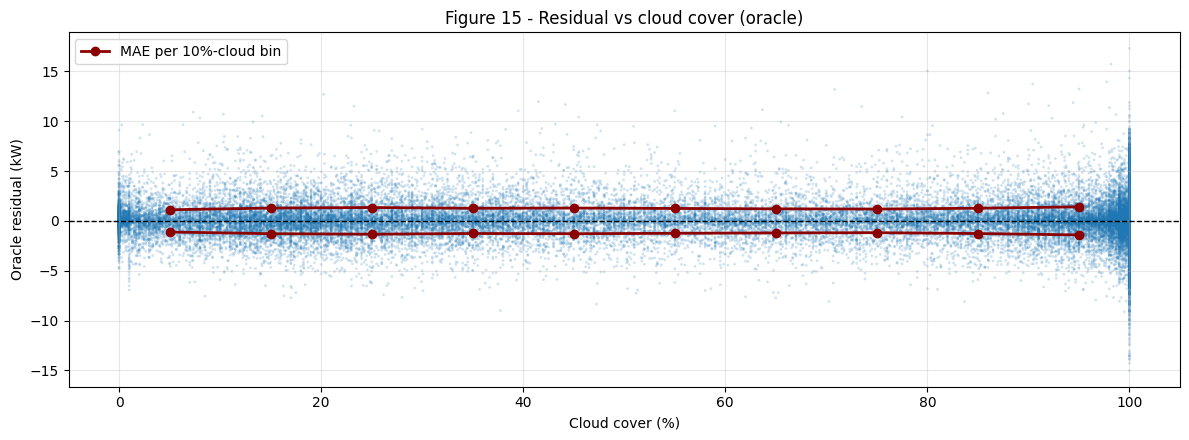

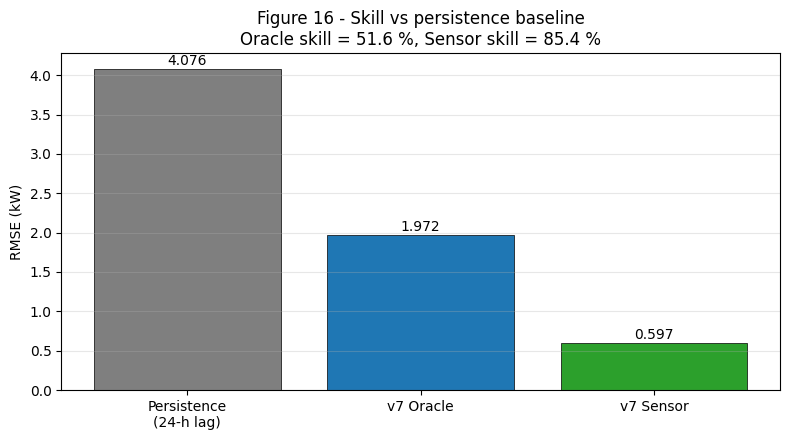

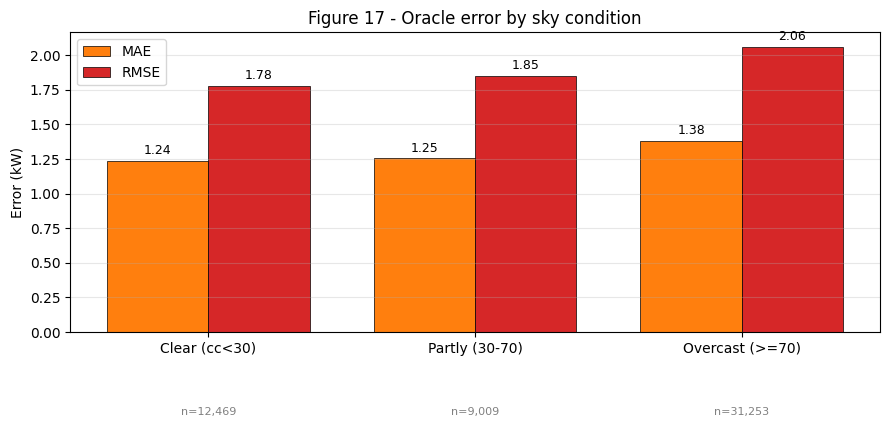

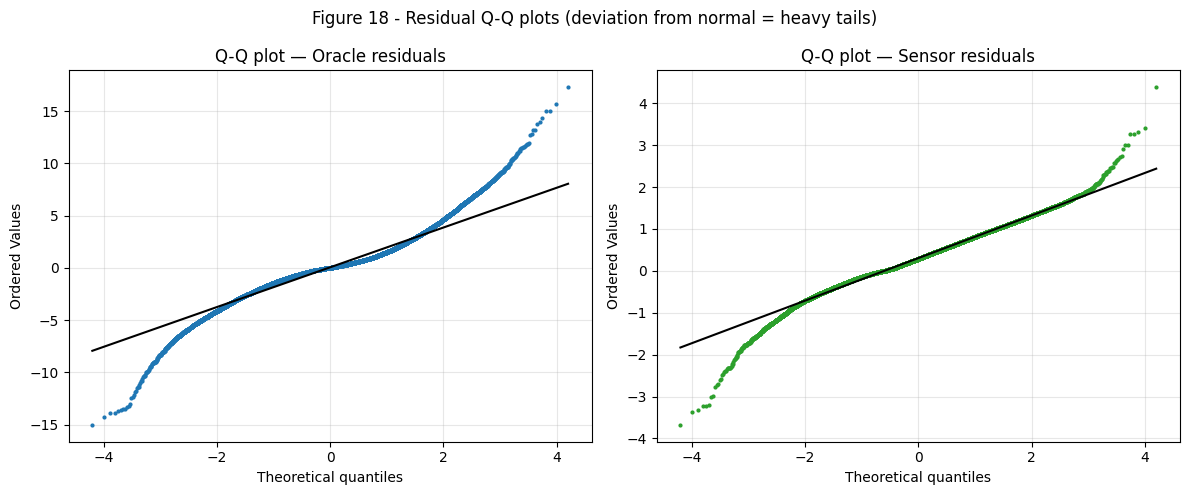

In [40]:
# Extended evaluation metrics
# Self-contained: re-derives `agg`, daily totals, and daytime masks from
# po_test / se_test so this cell runs even if cell 54 was not executed in
# the current kernel session.

from scipy.stats import pearsonr

# ---------------------------------------------------------------------------
# 0. Re-derive frames locally (no dependency on cell 54 variables)
# ---------------------------------------------------------------------------
agg = pd.DataFrame({
    "time":        po_test["time"].values,
    "actual":      po_test["power"].values,
    "pred_oracle": po_test["pred_oracle"].values,
    "pred_sensor": se_test["pred_sensor"].values,
    "cloud_cover": po_test["cloud_cover"].values if "cloud_cover" in po_test.columns else np.nan,
    "cs_irr":      po_test["cs_irr"].values,
})
agg["time"] = pd.to_datetime(agg["time"])
agg = agg.sort_values("time").reset_index(drop=True)
agg["date"]     = agg["time"].dt.normalize()
agg["hour_int"] = agg["time"].dt.hour

day_mask_o = (po_test["cs_irr"] > 10).values
day_mask_s = (se_test["cs_irr"] > 10).values
y_o = po_test.loc[day_mask_o, "power"].values
p_o = po_test.loc[day_mask_o, "pred_oracle"].values
y_s = se_test.loc[day_mask_s, "power"].values
p_s = se_test.loc[day_mask_s, "pred_sensor"].values

# Daily energy in kWh/day (5-min cadence -> sum * 5/60)
daily = agg.groupby("date").agg(actual=("actual", "sum"),
                                oracle=("pred_oracle", "sum"),
                                sensor=("pred_sensor", "sum")) * (5.0 / 60.0)
de_mae_o = float(np.mean(np.abs(daily["actual"] - daily["oracle"])))
de_mae_s = float(np.mean(np.abs(daily["actual"] - daily["sensor"])))

# ---------------------------------------------------------------------------
# 1. Persistence baseline (24-hour lag, 5-min cadence -> 288 steps/day)
# ---------------------------------------------------------------------------
PERS_LAG = 288
agg["persistence"] = agg["actual"].shift(PERS_LAG)
pers_mask = agg["persistence"].notna() & (agg["actual"] > 0.05)
y_pers   = agg.loc[pers_mask, "actual"].values
p_pers   = agg.loc[pers_mask, "persistence"].values
o_paired = agg.loc[pers_mask, "pred_oracle"].values
s_paired = agg.loc[pers_mask, "pred_sensor"].values

rmse_pers   = float(np.sqrt(np.mean((y_pers - p_pers) ** 2)))
rmse_oracle = float(np.sqrt(np.mean((y_pers - o_paired) ** 2)))
rmse_sensor = float(np.sqrt(np.mean((y_pers - s_paired) ** 2)))
skill_oracle = 1.0 - rmse_oracle / rmse_pers if rmse_pers > 0 else float("nan")
skill_sensor = 1.0 - rmse_sensor / rmse_pers if rmse_pers > 0 else float("nan")

# ---------------------------------------------------------------------------
# 2. Extended-metrics table (daytime, cs_irr > 10)
# ---------------------------------------------------------------------------
def _ext_metrics(y, p, rated):
    rmse = float(np.sqrt(np.mean((y - p) ** 2)))
    mae  = float(np.mean(np.abs(y - p)))
    bias = float(np.mean(p - y))
    r, _ = pearsonr(y, p)
    nse  = 1.0 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2)
    return {
        "RMSE (kW)":       rmse,
        "nRMSE (% rated)": 100.0 * rmse / rated,
        "MAE (kW)":        mae,
        "nMAE (% rated)":  100.0 * mae / rated,
        "Bias (kW)":       bias,
        "Pearson r":       float(r),
        "NSE":             float(nse),
    }

m_ext_oracle = _ext_metrics(y_o, p_o, RATED_KW)
m_ext_sensor = _ext_metrics(y_s, p_s, RATED_KW)
m_ext_oracle["Skill vs persistence"] = float(skill_oracle)
m_ext_sensor["Skill vs persistence"] = float(skill_sensor)

print("=" * 70)
print("EXTENDED METRICS - v7 daytime test set (cs_irr > 10)")
print("=" * 70)
print(f"{'Metric':<24}{'Oracle':>20}{'Sensor':>20}")
print("-" * 70)
for k in m_ext_oracle:
    print(f"{k:<24}{m_ext_oracle[k]:>20.4f}{m_ext_sensor[k]:>20.4f}")
print("-" * 70)
print(f"Persistence RMSE (kW)   = {rmse_pers:.4f}   (24-hour lag baseline)")

# ---------------------------------------------------------------------------
# 3. Per-sky-condition MAE breakdown (oracle predictions)
# ---------------------------------------------------------------------------
if "cloud_cover" in po_test.columns:
    sky = po_test.loc[day_mask_o, ["power", "pred_oracle", "cloud_cover"]].copy()
    def _sky_label(cc):
        if cc < 30:  return "Clear (cc<30)"
        if cc < 70:  return "Partly (30-70)"
        return "Overcast (>=70)"
    sky["sky"] = sky["cloud_cover"].apply(_sky_label)
    sky_metrics = sky.groupby("sky").apply(
        lambda g: pd.Series({
            "n":           len(g),
            "MAE (kW)":    float(np.mean(np.abs(g["power"] - g["pred_oracle"]))),
            "RMSE (kW)":   float(np.sqrt(np.mean((g["power"] - g["pred_oracle"]) ** 2))),
            "mean actual": float(g["power"].mean()),
            "mean pred":   float(g["pred_oracle"].mean()),
        }),
        include_groups=False,
    )
    print("\nPer-sky-condition errors (oracle, daytime):")
    print(sky_metrics.round(3).to_string())
else:
    print("\n(cloud_cover not in po_test — sky-condition breakdown skipped)")

# ---------------------------------------------------------------------------
# 4. Capacity Factor comparison (full test set, all hours)
# ---------------------------------------------------------------------------
cf_actual = float(agg["actual"].mean()      / RATED_KW)
cf_oracle = float(agg["pred_oracle"].mean() / RATED_KW)
cf_sensor = float(agg["pred_sensor"].mean() / RATED_KW)
print("\nCapacity Factor (mean power / rated):")
print(f"  Actual          : {cf_actual*100:>6.2f} %")
print(f"  v7 oracle pred  : {cf_oracle*100:>6.2f} %   (delta {(cf_oracle-cf_actual)*100:+.2f} pp)")
print(f"  v7 sensor pred  : {cf_sensor*100:>6.2f} %   (delta {(cf_sensor-cf_actual)*100:+.2f} pp)")

# ---------------------------------------------------------------------------
# 5. Daily-energy nMAE (% of mean daily kWh)
# ---------------------------------------------------------------------------
mean_daily = float(daily["actual"].mean())
nmae_e_o = de_mae_o / mean_daily * 100 if mean_daily > 0 else float("nan")
nmae_e_s = de_mae_s / mean_daily * 100 if mean_daily > 0 else float("nan")
print(f"\nDaily energy nMAE (% of mean daily kWh = {mean_daily:.1f}):")
print(f"  Oracle: {nmae_e_o:>6.2f} %")
print(f"  Sensor: {nmae_e_s:>6.2f} %")


# ===========================================================================
# GRAPHICAL ANALYSIS — extended diagnostic plots
# ===========================================================================

# Figure 13 - Predicted vs Actual scatter (oracle + sensor side-by-side)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, y, p, title, colour in [
    (axes[0], y_o, p_o, "Oracle (day-ahead)",    "tab:blue"),
    (axes[1], y_s, p_s, "Sensor (real-time)",    "tab:green"),
]:
    ax.scatter(y, p, s=4, alpha=0.20, color=colour, edgecolor="none")
    lim = max(y.max(), p.max()) * 1.02
    ax.plot([0, lim], [0, lim], "k--", lw=1.2, label="Perfect")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Actual power (kW)")
    ax.set_ylabel("Predicted power (kW)")
    r2 = 1.0 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2)
    ax.set_title(f"{title}\nR² = {r2:.4f}, n = {len(y):,}")
    ax.grid(alpha=0.3); ax.legend(loc="upper left")
plt.suptitle("Figure 13 - Predicted vs actual scatter (daytime)")
plt.tight_layout(); plt.show()

# Figure 14 - Residual histograms (error distribution)
# ---------------------------------------------------------------------------
res_o = p_o - y_o
res_s = p_s - y_s
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.hist(res_o, bins=80, alpha=0.55, color="tab:blue",  label=f"Oracle (μ={res_o.mean():+.3f}, σ={res_o.std():.3f})")
ax.hist(res_s, bins=80, alpha=0.55, color="tab:green", label=f"Sensor (μ={res_s.mean():+.3f}, σ={res_s.std():.3f})")
ax.axvline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Residual = predicted - actual (kW)")
ax.set_ylabel("Count")
ax.set_title("Figure 14 - Residual distribution (daytime test set)")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Figure 15 - Residual vs cloud cover (heteroscedasticity check)
# ---------------------------------------------------------------------------
if "cloud_cover" in po_test.columns:
    cc_o = po_test.loc[day_mask_o, "cloud_cover"].values
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.scatter(cc_o, res_o, s=4, alpha=0.20, color="tab:blue", edgecolor="none")
    bins = np.arange(0, 101, 10)
    centres = (bins[:-1] + bins[1:]) / 2
    bin_idx = np.clip(np.digitize(cc_o, bins) - 1, 0, len(centres) - 1)
    bin_mae = np.array([np.mean(np.abs(res_o[bin_idx == i])) if (bin_idx == i).any() else np.nan
                        for i in range(len(centres))])
    ax.plot(centres, bin_mae,  "o-", color="darkred", lw=2, label="MAE per 10%-cloud bin")
    ax.plot(centres, -bin_mae, "o-", color="darkred", lw=2)
    ax.axhline(0, color="black", lw=1, ls="--")
    ax.set_xlabel("Cloud cover (%)")
    ax.set_ylabel("Oracle residual (kW)")
    ax.set_title("Figure 15 - Residual vs cloud cover (oracle)")
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

# Figure 16 - Skill vs persistence baseline (RMSE comparison)
# ---------------------------------------------------------------------------
labels = ["Persistence\n(24-h lag)", "v7 Oracle", "v7 Sensor"]
rmse_vals = [rmse_pers, rmse_oracle, rmse_sensor]
colours = ["tab:gray", "tab:blue", "tab:green"]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, rmse_vals, color=colours, edgecolor="black", linewidth=0.5)
for b, v in zip(bars, rmse_vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.3f}",
            ha="center", fontsize=10)
ax.set_ylabel("RMSE (kW)")
ax.set_title(f"Figure 16 - Skill vs persistence baseline\n"
             f"Oracle skill = {skill_oracle*100:.1f} %, Sensor skill = {skill_sensor*100:.1f} %")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Figure 17 - Per-sky-condition error bars (oracle)
# ---------------------------------------------------------------------------
if "cloud_cover" in po_test.columns:
    cats = ["Clear (cc<30)", "Partly (30-70)", "Overcast (>=70)"]
    cat_mae  = []
    cat_rmse = []
    cat_n    = []
    for label in cats:
        if label in sky_metrics.index:
            cat_mae.append(sky_metrics.loc[label,  "MAE (kW)"])
            cat_rmse.append(sky_metrics.loc[label, "RMSE (kW)"])
            cat_n.append(int(sky_metrics.loc[label, "n"]))
        else:
            cat_mae.append(0); cat_rmse.append(0); cat_n.append(0)
    x = np.arange(len(cats)); width = 0.38
    fig, ax = plt.subplots(figsize=(9, 4.5))
    b1 = ax.bar(x - width/2, cat_mae,  width, color="tab:orange", edgecolor="black",
                linewidth=0.5, label="MAE")
    b2 = ax.bar(x + width/2, cat_rmse, width, color="tab:red",    edgecolor="black",
                linewidth=0.5, label="RMSE")
    for i, (m, r, n) in enumerate(zip(cat_mae, cat_rmse, cat_n)):
        ax.text(i - width/2, m + 0.05, f"{m:.2f}", ha="center", fontsize=9)
        ax.text(i + width/2, r + 0.05, f"{r:.2f}", ha="center", fontsize=9)
        ax.text(i, -0.6, f"n={n:,}", ha="center", fontsize=8, color="gray")
    ax.set_xticks(x); ax.set_xticklabels(cats)
    ax.set_ylabel("Error (kW)")
    ax.set_title("Figure 17 - Oracle error by sky condition")
    ax.grid(axis="y", alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

# Figure 18 - Q-Q plot of residuals (normality check)
# ---------------------------------------------------------------------------
from scipy import stats as _stats
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, name, colour in [
    (axes[0], res_o, "Oracle", "tab:blue"),
    (axes[1], res_s, "Sensor", "tab:green"),
]:
    _stats.probplot(res, dist="norm", plot=ax)
    ax.get_lines()[0].set_markerfacecolor(colour)
    ax.get_lines()[0].set_markeredgecolor(colour)
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color("black")
    ax.set_title(f"Q-Q plot — {name} residuals")
    ax.grid(alpha=0.3)
plt.suptitle("Figure 18 - Residual Q-Q plots (deviation from normal = heavy tails)")
plt.tight_layout(); plt.show()


## 18. Predict from a weather-forecast CSV

Generic prediction module. Set `PREDICT_CSV` to any forecast file with at minimum:

- a time column (`time`, `datetime`, or `date`)
- temperature, humidity, wind speed, precipitation, cloud cover


Output: written as `results_<input-stem>.csv` next to the input file. Plus four
diagnostic plots and a per-day summary table.


Input columns: ['latitude', 'longitude', 'datetime', 'temp', 'humidity', 'precip', 'windspeed', 'cloudcover']
Normalised columns: ['latitude', 'longitude', 'time', 'temp', 'humidity', 'precipitation', 'wind_speed', 'cloud_cover']
Loaded 336 hourly rows: 2026-05-14 00:00:00 -> 2026-05-27 23:00:00
Cloud layer breakdown not present; synthesising from C:\Solar_SUDHA_maam\cloud_split_climatology.csv
  cloud_cover_low  range: [0.3, 15.5]
  cloud_cover_mid  range: [1.0, 34.1]
  cloud_cover_high range: [4.5, 98.2]
5-min target grid: 4,020 rows
Predictions written: C:\Solar_SUDHA_maam\results_predict_2.csv  (4,020 rows, 262.1 KB)

Daily summary (14 days):
            energy_kwh  peak_kw  mean_temp  mean_cc  mean_hum
date                                                         
2026-05-14      303.94    35.68      30.11    92.56     71.59
2026-05-15      303.52    37.19      31.31    96.62     67.85
2026-05-16      318.61    36.75      31.81    76.94     62.97
2026-05-17      303.03    34.95    

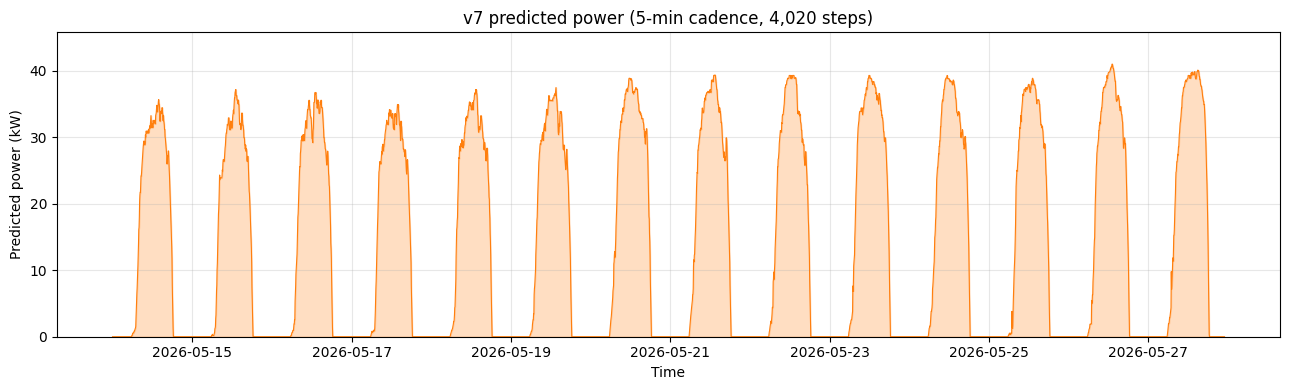

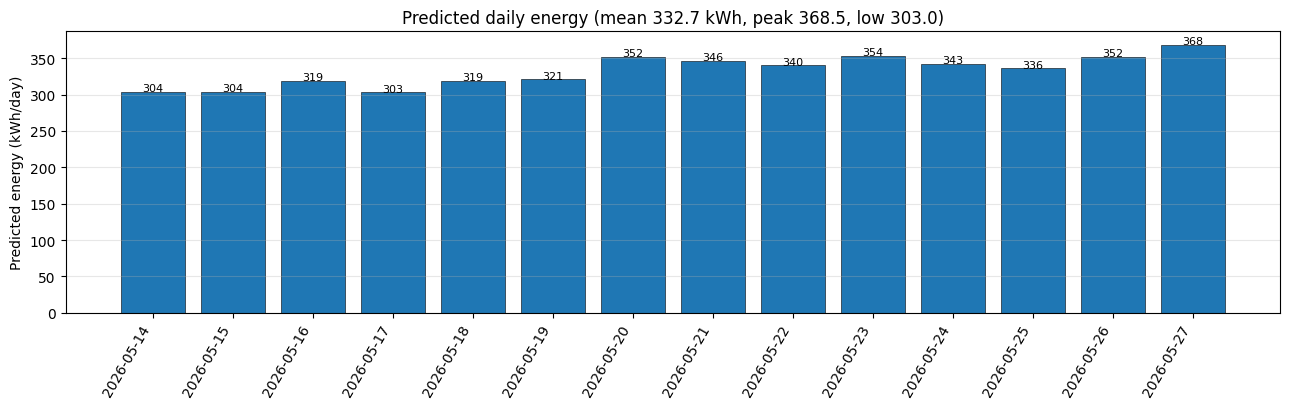

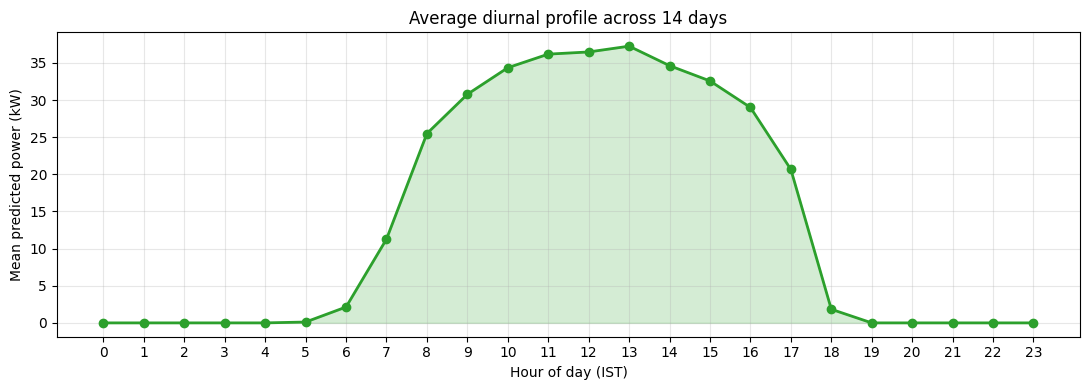

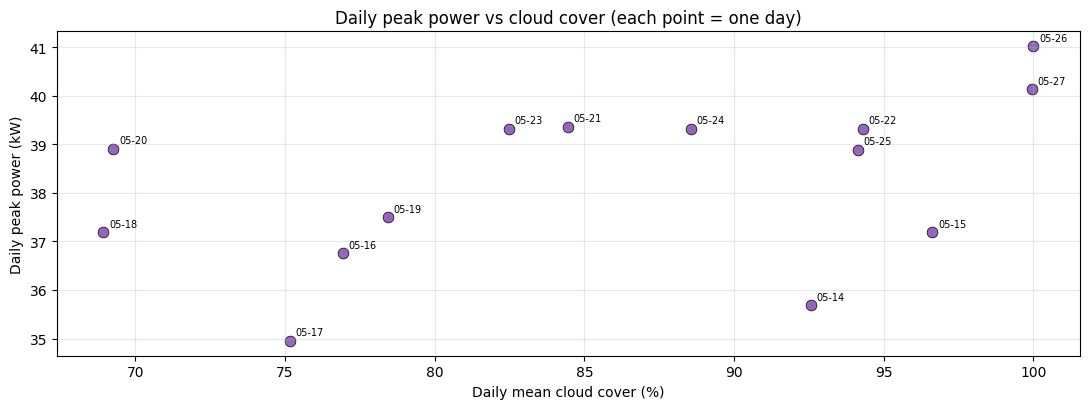


PREDICTION SUMMARY
  Forecast horizon       : 2026-05-14 00:00:00 -> 2026-05-27 23:00:00  (14 days)
  Total predicted energy : 4,658.5 kWh
  Mean daily energy      : 332.7 kWh/day
  Mean daily peak power  : 38.3 kW   (rated = 43.625 kW)
  Best day               : 2026-05-27  (368.5 kWh)
  Worst day              : 2026-05-17  (303.0 kWh)
  Total hours above 30 kW: 92
  Output CSV             : C:\Solar_SUDHA_maam\results_predict_2.csv


In [41]:
# ---------------------------------------------------------------------------
# CONFIG: change PREDICT_CSV and re-run; nothing else needs editing.
# ---------------------------------------------------------------------------
PREDICT_CSV   = r"C:\Solar_SUDHA_maam\predict_2.csv"
CLIMATOLOGY   = r"C:\Solar_SUDHA_maam\cloud_split_climatology.csv"  # auto-built once

# ---------------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

assert os.path.exists(PREDICT_CSV), f"Input not found: {PREDICT_CSV}"

raw = pd.read_csv(PREDICT_CSV)
print(f"Input columns: {list(raw.columns)}")

# ---------------------------------------------------------------------------
# 1. Tolerant column normalisation. Handles Open-Meteo style, Visual Crossing
#    style, and the compact predict1.csv style.
# ---------------------------------------------------------------------------
colmap = {}
for c in raw.columns:
    lc = c.strip().lower()
    if   lc.startswith("time") or lc.startswith("datetime") or lc == "date":
        colmap[c] = "time"
    elif lc.startswith("temperature") or lc == "temp":
        colmap[c] = "temp"
    elif lc.startswith("relative_humidity") or lc.startswith("humidity") or lc == "rh":
        colmap[c] = "humidity"
    elif lc.startswith("wind_speed") or lc.startswith("windspeed") or lc == "wind":
        colmap[c] = "wind_speed"
    elif lc.startswith("precipitation") or lc.startswith("precip") or lc == "rain":
        colmap[c] = "precipitation"
    elif lc.startswith("cloud_cover_low") or lc == "cloudcover_low":
        colmap[c] = "cloud_cover_low"
    elif lc.startswith("cloud_cover_mid") or lc == "cloudcover_mid":
        colmap[c] = "cloud_cover_mid"
    elif lc.startswith("cloud_cover_high") or lc == "cloudcover_high":
        colmap[c] = "cloud_cover_high"
    elif lc.startswith("cloud_cover") or lc.startswith("cloudcover") or lc == "cc":
        colmap[c] = "cloud_cover"
raw = raw.rename(columns=colmap)
print(f"Normalised columns: {list(raw.columns)}")

required_min = ["time","temp","humidity","wind_speed","precipitation","cloud_cover"]
miss_min = [c for c in required_min if c not in raw.columns]
assert not miss_min, f"Missing required columns: {miss_min}"

raw["time"] = pd.to_datetime(raw["time"])
raw = raw.sort_values("time").drop_duplicates("time").reset_index(drop=True)
print(f"Loaded {len(raw):,} hourly rows: {raw['time'].min()} -> {raw['time'].max()}")

# Synthesise low/mid/high from total cloud_cover using climatology when missing.
have_layers = all(c in raw.columns for c in ["cloud_cover_low","cloud_cover_mid","cloud_cover_high"])
if not have_layers:
    print(f"Cloud layer breakdown not present; synthesising from {CLIMATOLOGY}")
    assert os.path.exists(CLIMATOLOGY), \
        f"Climatology table missing: {CLIMATOLOGY} (run cloud_split_climatology builder once)"
    clim = pd.read_csv(CLIMATOLOGY)
    raw["mo"] = raw["time"].dt.month
    raw["hr"] = raw["time"].dt.hour
    raw = raw.merge(clim, on=["mo","hr"], how="left")
    raw["cloud_cover_low"]  = (raw["cloud_cover"] * raw["lo_frac"]).clip(0, 100)
    raw["cloud_cover_mid"]  = (raw["cloud_cover"] * raw["mi_frac"]).clip(0, 100)
    raw["cloud_cover_high"] = (raw["cloud_cover"] * raw["hi_frac"]).clip(0, 100)
    raw = raw.drop(columns=["mo","hr","lo_frac","mi_frac","hi_frac"])
    print(f"  cloud_cover_low  range: [{raw['cloud_cover_low'].min():.1f}, {raw['cloud_cover_low'].max():.1f}]")
    print(f"  cloud_cover_mid  range: [{raw['cloud_cover_mid'].min():.1f}, {raw['cloud_cover_mid'].max():.1f}]")
    print(f"  cloud_cover_high range: [{raw['cloud_cover_high'].min():.1f}, {raw['cloud_cover_high'].max():.1f}]")
else:
    print("Cloud layer breakdown present in input; using as-is.")

# ---------------------------------------------------------------------------
# 2. Build 5-min target grid spanning the input range
# ---------------------------------------------------------------------------
start = raw["time"].iloc[0].floor("h")
end   = raw["time"].iloc[-1].ceil("h")
t5    = pd.date_range(start, end, freq="5min", inclusive="left")
fm    = pd.DataFrame({"time": t5})
print(f"5-min target grid: {len(fm):,} rows")

t_h = raw["time"].astype("int64").to_numpy() // 10**9
t_q = fm["time"].astype("int64").to_numpy() // 10**9
for col in ["temp","humidity","wind_speed",
            "cloud_cover","cloud_cover_low","cloud_cover_mid","cloud_cover_high"]:
    pchip = PchipInterpolator(t_h, raw[col].values, extrapolate=False)
    v = pchip(t_q.astype(float))
    v = np.where(np.isnan(v), np.interp(t_q, t_h, raw[col].values), v)
    fm[col] = v
fm["humidity"]   = fm["humidity"].clip(0, 100)
fm["wind_speed"] = fm["wind_speed"].clip(0)
for cc in ["cloud_cover","cloud_cover_low","cloud_cover_mid","cloud_cover_high"]:
    fm[cc] = fm[cc].clip(0, 100)

prec = np.zeros(len(t5))
fm["_floor_h"] = fm["time"].dt.floor("h")
hourly_p = raw.set_index("time")["precipitation"]
for h, p in hourly_p.items():
    if p <= 0:
        continue
    mask = (fm["_floor_h"] == h).values
    if mask.sum():
        prec[mask] = p / mask.sum()
fm["precipitation"] = prec
fm.drop(columns=["_floor_h"], inplace=True)

# ---------------------------------------------------------------------------
# 3. Compute v7 features (uses notebook's compute_features from section 13)
# ---------------------------------------------------------------------------
fm_feats = compute_features(fm)
fm_feats["cs_power"] = fm_feats["cs_irr"] * AREA_EFF / 1000

# ---------------------------------------------------------------------------
# 4. Predict with power_model_v7
# ---------------------------------------------------------------------------
pred = np.clip(power_model_v7.predict(fm_feats[FEATURES_ORACLE]), 0, None)
pred = np.minimum(pred, fm_feats["theo_power_est"].values).clip(0, RATED_KW)
pred[fm_feats["solar_elev"].values <= 0] = 0.0

out = pd.DataFrame({
    "time":              fm_feats["time"],
    "predicted_power":   np.round(pred, 3),
    "predicted_irr":     np.round(fm_feats["irr_est"].values, 1),
    "kt_est":            np.round(fm_feats["kt_est"].values, 4),
    "cs_irr":            np.round(fm_feats["cs_irr"].values, 1),
    "temp":              np.round(fm_feats["temp"].values, 2),
    "humidity":          np.round(fm_feats["humidity"].values, 2),
    "cloud_cover":       np.round(fm_feats["cloud_cover"].values, 1),
    "wind_speed":        np.round(fm_feats["wind_speed"].values, 2),
    "precipitation":     np.round(fm_feats["precipitation"].values, 4),
})

input_stem = os.path.splitext(os.path.basename(PREDICT_CSV))[0]
out_path   = os.path.join(os.path.dirname(PREDICT_CSV), f"results_{input_stem}.csv")
out.to_csv(out_path, index=False)
print(f"Predictions written: {out_path}  ({len(out):,} rows, {os.path.getsize(out_path)/1024:.1f} KB)")

# ---------------------------------------------------------------------------
# 5. Diagnostics: per-day summary + 4 plots
# ---------------------------------------------------------------------------
out["date"]     = out["time"].dt.date
out["hour_int"] = out["time"].dt.hour

daily = out.groupby("date").agg(
    energy_kwh=("predicted_power", lambda x: x.sum() * 5 / 60),
    peak_kw   =("predicted_power", "max"),
    mean_temp =("temp", "mean"),
    mean_cc   =("cloud_cover", "mean"),
    mean_hum  =("humidity", "mean"),
)
print(f"\nDaily summary ({len(daily)} days):")
print(daily.round(2).to_string())

# Figure 1 - 5-min predicted power timeline
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(out["time"], out["predicted_power"], color="tab:orange", lw=0.8)
ax.fill_between(out["time"], 0, out["predicted_power"], color="tab:orange", alpha=0.25)
ax.set_ylabel("Predicted power (kW)")
ax.set_xlabel("Time")
ax.set_title(f"v7 predicted power (5-min cadence, {len(out):,} steps)")
ax.set_ylim(0, RATED_KW * 1.05)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Figure 2 - daily energy bar chart
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.bar(range(len(daily)), daily["energy_kwh"].values,
       color="tab:blue", edgecolor="black", linewidth=0.4)
ax.set_xticks(range(len(daily)))
ax.set_xticklabels([str(d) for d in daily.index], rotation=60, ha="right")
ax.set_ylabel("Predicted energy (kWh/day)")
ax.set_title(f"Predicted daily energy (mean {daily['energy_kwh'].mean():.1f} kWh, "
             f"peak {daily['energy_kwh'].max():.1f}, low {daily['energy_kwh'].min():.1f})")
for i, v in enumerate(daily["energy_kwh"].values):
    ax.text(i, v + 1, f"{v:.0f}", ha="center", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Figure 3 - hour-of-day diurnal profile
hod = out.groupby("hour_int")["predicted_power"].mean()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hod.index, hod.values, "-o", color="tab:green", lw=2)
ax.fill_between(hod.index, 0, hod.values, color="tab:green", alpha=0.2)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day (IST)")
ax.set_ylabel("Mean predicted power (kW)")
ax.set_title(f"Average diurnal profile across {len(daily)} days")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Figure 4 - peak vs cloud cover
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.scatter(daily["mean_cc"], daily["peak_kw"], s=60,
           color="tab:purple", edgecolor="black", linewidth=0.5)
for d, r in daily.iterrows():
    ax.annotate(str(d)[5:], (r["mean_cc"], r["peak_kw"]),
                xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.set_xlabel("Daily mean cloud cover (%)")
ax.set_ylabel("Daily peak power (kW)")
ax.set_title("Daily peak power vs cloud cover (each point = one day)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------------
# 6. Summary print
# ---------------------------------------------------------------------------
total_energy   = out["predicted_power"].sum() * 5 / 60
mean_daily_kwh = daily["energy_kwh"].mean()
peak_day       = daily["energy_kwh"].idxmax()
worst_day      = daily["energy_kwh"].idxmin()
mean_peak      = daily["peak_kw"].mean()
hours_above_30 = int((out["predicted_power"] > 30).sum() * 5 / 60)

print("\n" + "=" * 64)
print("PREDICTION SUMMARY")
print("=" * 64)
print(f"  Forecast horizon       : {start} -> {end}  ({len(daily)} days)")
print(f"  Total predicted energy : {total_energy:,.1f} kWh")
print(f"  Mean daily energy      : {mean_daily_kwh:.1f} kWh/day")
print(f"  Mean daily peak power  : {mean_peak:.1f} kW   (rated = {RATED_KW} kW)")
print(f"  Best day               : {peak_day}  ({daily.loc[peak_day,'energy_kwh']:.1f} kWh)")
print(f"  Worst day              : {worst_day}  ({daily.loc[worst_day,'energy_kwh']:.1f} kWh)")
print(f"  Total hours above 30 kW: {hours_above_30}")
print(f"  Output CSV             : {out_path}")
